In [3]:
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("insurance_t.csv")
df.head()

,ACCTAGE,DDA,DDABAL,DEP,DEPAMT,CHECKS,DIRDEP,NSF,NSFAMT,PHONE,...,CCPURC,SDB,INCOME,LORES,HMVAL,AGE,CRSCORE,INAREA,INS,BRANCH
0,0.7,1,1986.81,1,446.93,1,1,0,0.00,0.0,...,1.0,0,4.0,7.0,87.0,51.0,674.0,1,0,B2
1,4.1,0,0.00,0,0.00,0,0,0,0.00,0.0,...,0.0,0,30.0,8.5,97.0,60.0,640.0,1,1,B3
2,12.3,1,1069.78,5,6813.58,13,1,0,0.00,2.0,...,0.0,0,19.0,3.0,107.0,55.0,662.0,1,1,B7
3,0.8,1,190.03,3,880.25,1,0,1,5.65,NaN,...,NaN,1,20.0,4.0,107.0,40.0,642.0,1,0,B14
4,1.6,1,257.13,5,3408.35,14,0,1,60.25,NaN,...,NaN,0,24.0,8.5,95.0,54.0,732.0,1,0,B15


#### i. Data

In [25]:
# big outlier with POSAMT, PHONE
cats_to_impute = [ "CC","PHONE", "INV"]
cont_to_impute = ["CRSCORE", "ACCTAGE", "CCPURC","AGE", "HMVAL", "LORES", 
                  "INCOME", "INVBAL", "CCBAL","POSAMT","POS", 
                  "CC","PHONE", "INV","CCPURC","ACCTAGE","CRSCORE"]

In [26]:
conts = ["DEP","PHONE","TELLER","POS","LORES","CHECKS","AGE","INVBAL","HMVAL","INCOME","CRSCORE","CDBAL","ACCTAGE","IRABAL","NSFAMT","MMBAL","POSAMT","CCBAL","SAVBAL","ATMAMT","DEPAMT","DDABAL"]

cats = ["ATM","MM","INV","SDB","IRA","CD","SAV","CC","DIRDEP","NSF","DDA","INAREA","CCPURC","MMCRED","BRANCH"]

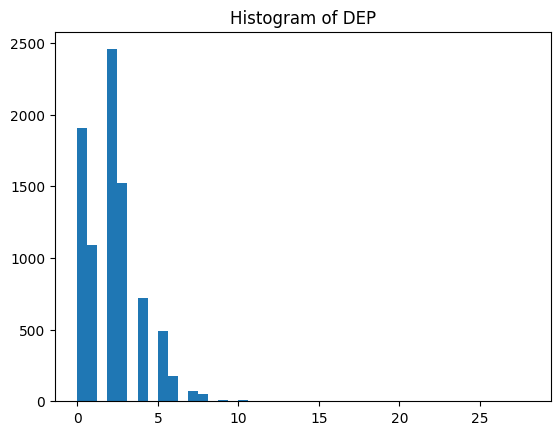

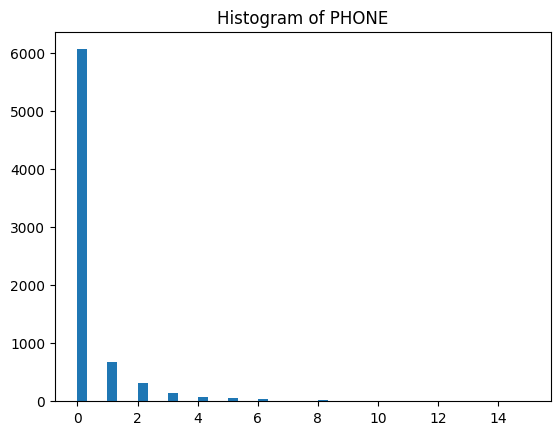

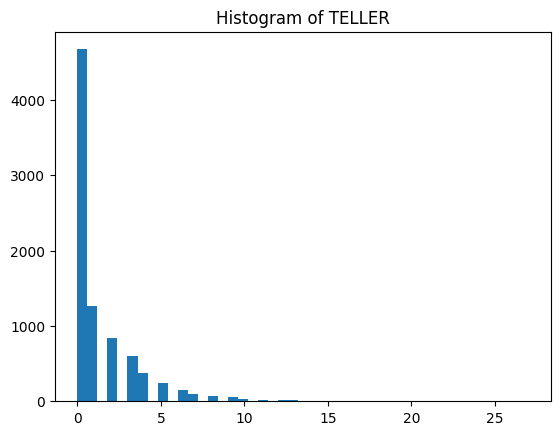

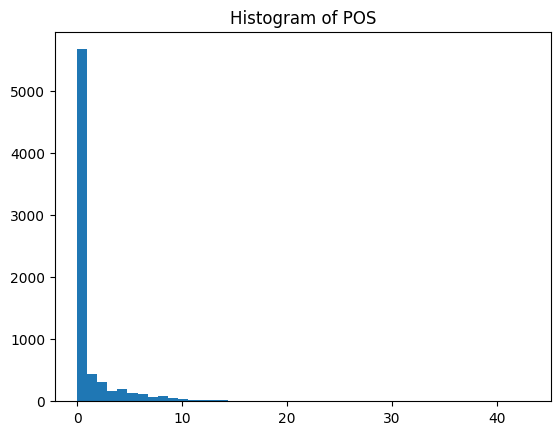

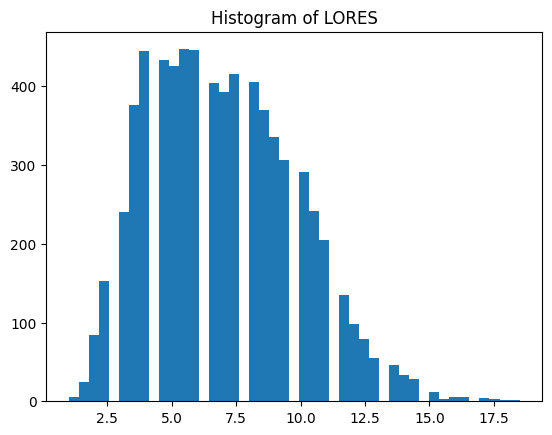

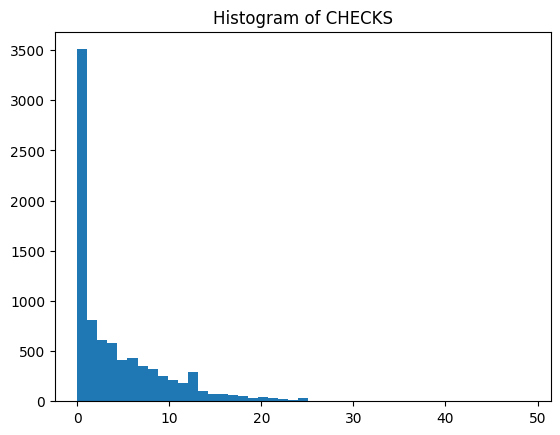

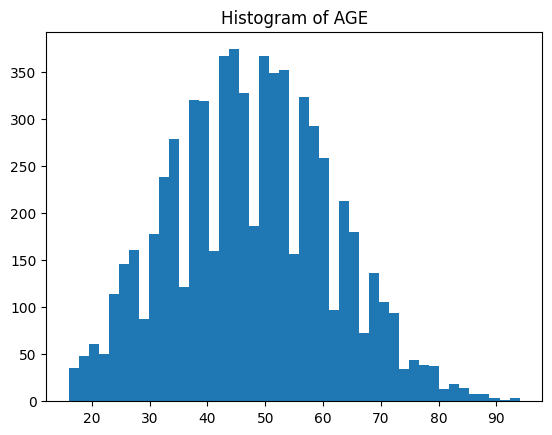

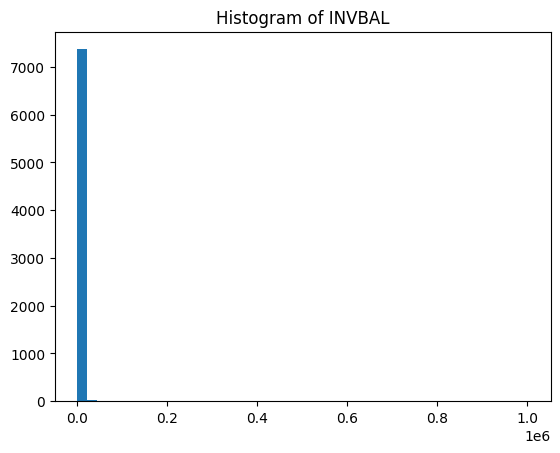

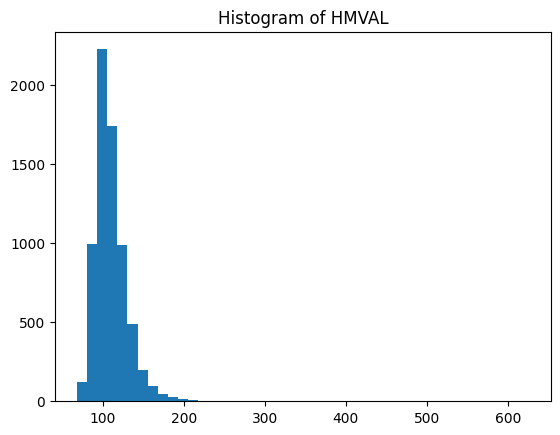

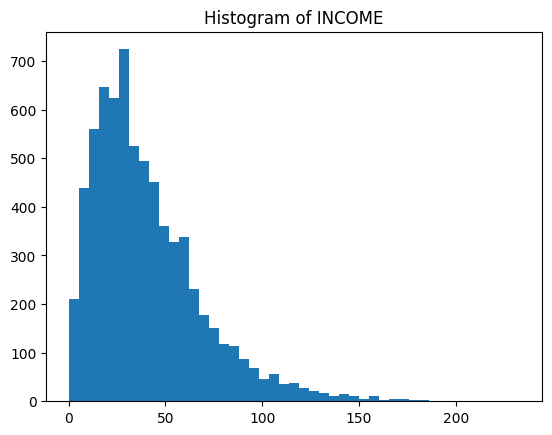

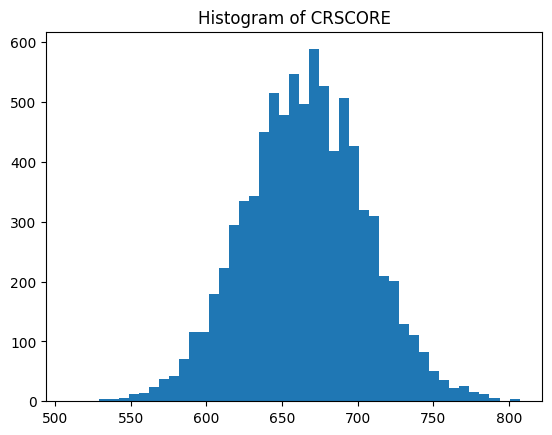

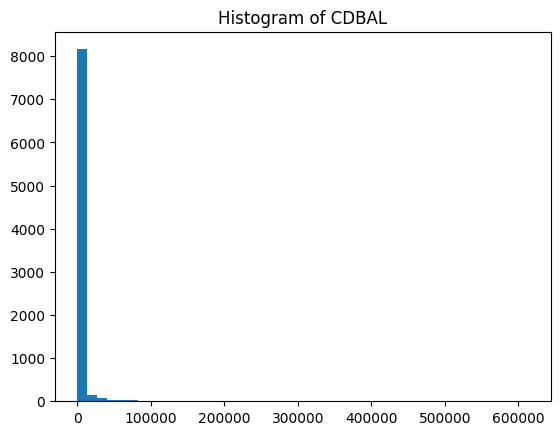

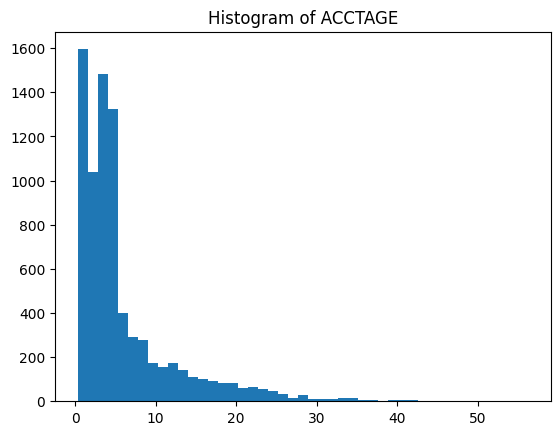

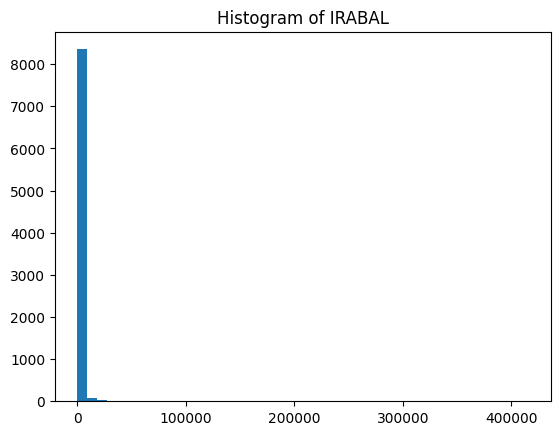

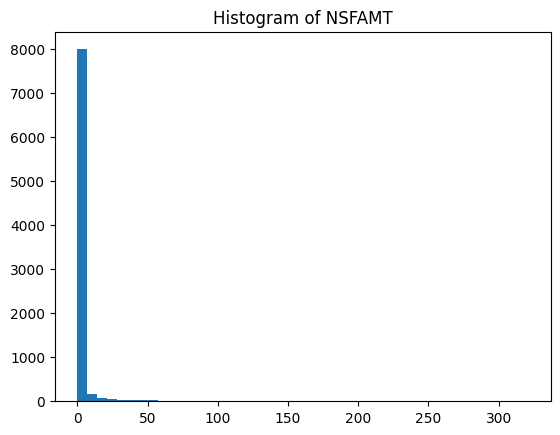

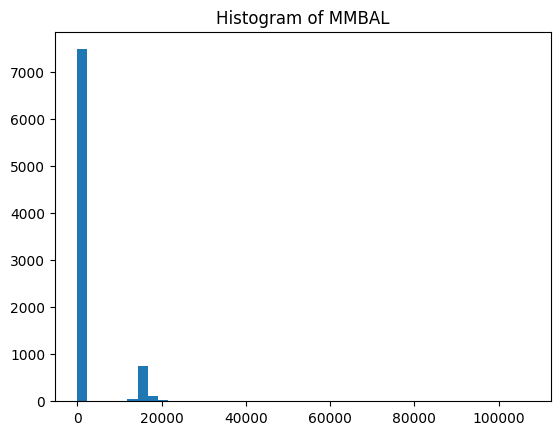

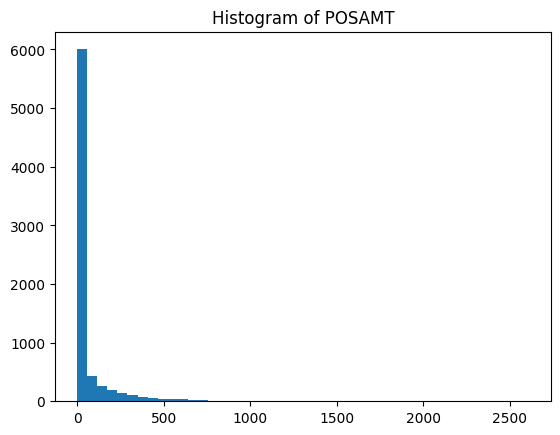

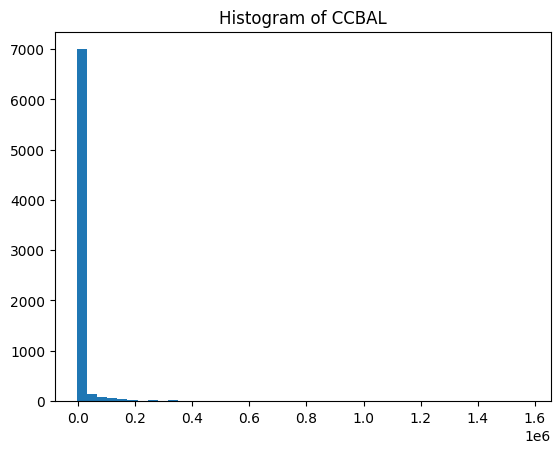

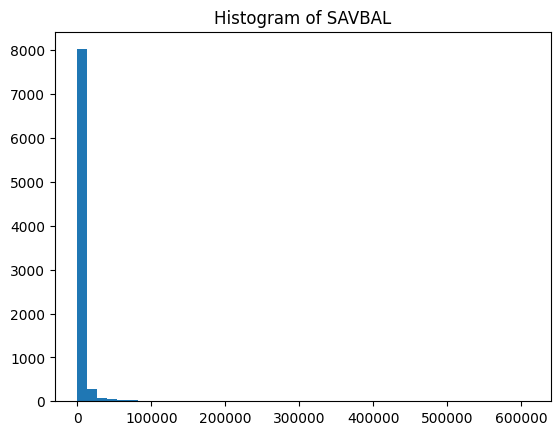

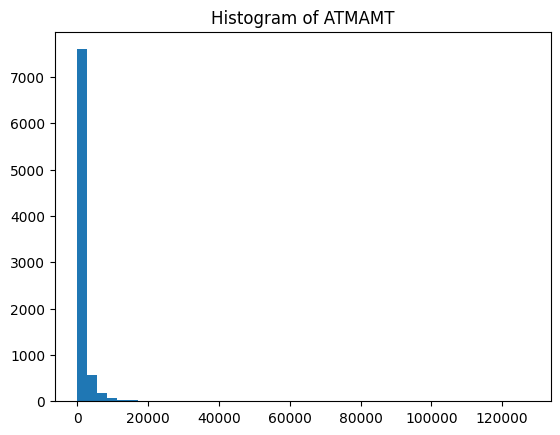

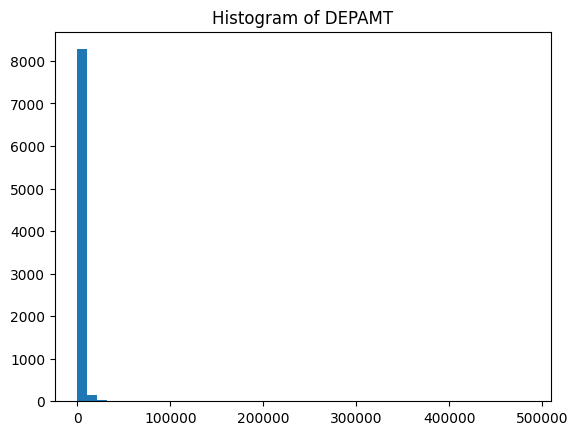

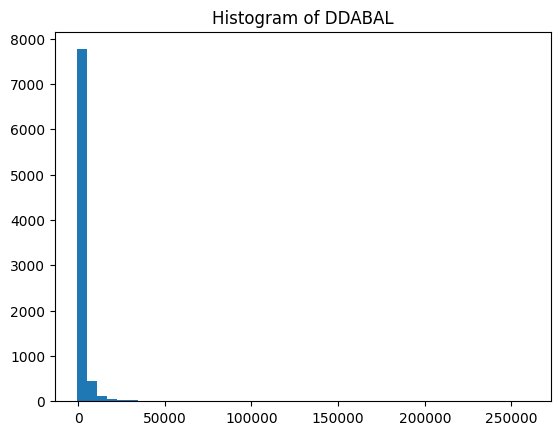

In [6]:
for col in conts:
    plt.title(f"Histogram of {col}")
    plt.hist(df[col], bins = 45)
    plt.show()


In [7]:
outliers = ['DDABAL','DEPAMT','NSFAMT','SAVBAL','ATMAMT','POSAMT','CDBAL','IRABAL','INVBAL',
       'MMBAL', 'CCBAL','HMVAL']

df_outliers = df[outliers]

df_outliers.describe()

,DDABAL,DEPAMT,NSFAMT,SAVBAL,ATMAMT,POSAMT,CDBAL,IRABAL,INVBAL,MMBAL,CCBAL,HMVAL
count,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,7420.000000,8495.000000,8495.000000,7.420000e+03,8495.000000,7.420000e+03,6958.000000
mean,2176.968640,2230.831261,2.312651,3114.228523,1192.404497,49.746699,2417.633902,693.038341,1.023959e+03,1985.427474,9.165378e+03,110.902414
std,7652.791186,7240.112143,13.619296,13557.326460,3845.197638,139.191726,14283.581865,8064.445750,1.990247e+04,5751.711083,4.950290e+04,22.641264
min,-399.530000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-1.903990e+03,69.000000
25%,53.185000,124.950000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,97.000000
50%,563.420000,1095.510000,0.000000,0.000000,119.910000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,107.000000
75%,1834.300000,2467.580000,0.000000,1195.435000,1173.830000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,3.954275e+02,120.000000
max,259734.260000,484893.670000,321.100000,609587.720000,127403.360000,2608.430000,613600.000000,415656.630000,1.002678e+06,107028.550000,1.576808e+06,625.000000


#### Note on the columns above:
- significant outliers
- prune by setting range to 3 std deviations above mean

#### Loop through each column and filter out outliers
for col in outliers:
    # Calculate mean and standard deviation for each column
    mean = df[col].mean()
    std_dev = df[col].std()
    
    # Define upper limit as mean + 3*std_dev
    upper_limit = mean + 3 * std_dev
    
    # Filter the DataFrame to keep rows within the limit
    df = df[df[col] <= upper_limit]

#### Visualize distributions with the target variable

In [8]:
import seaborn as sns

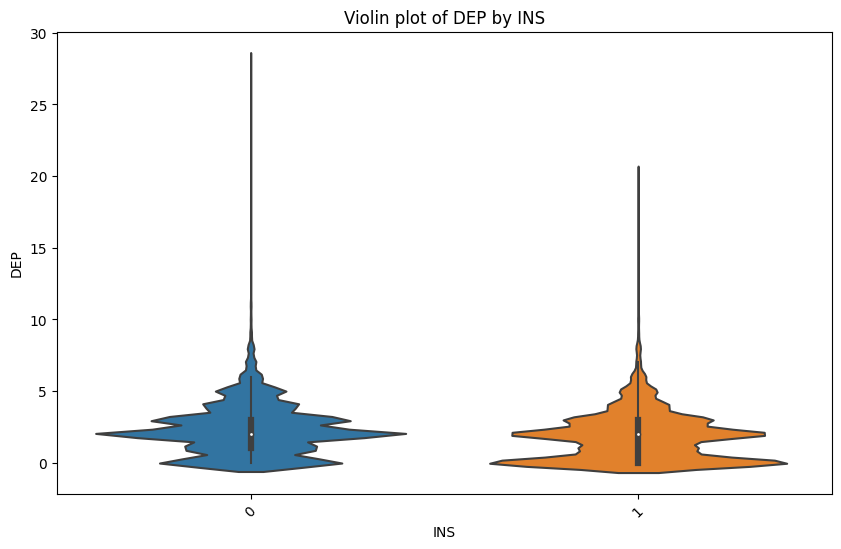

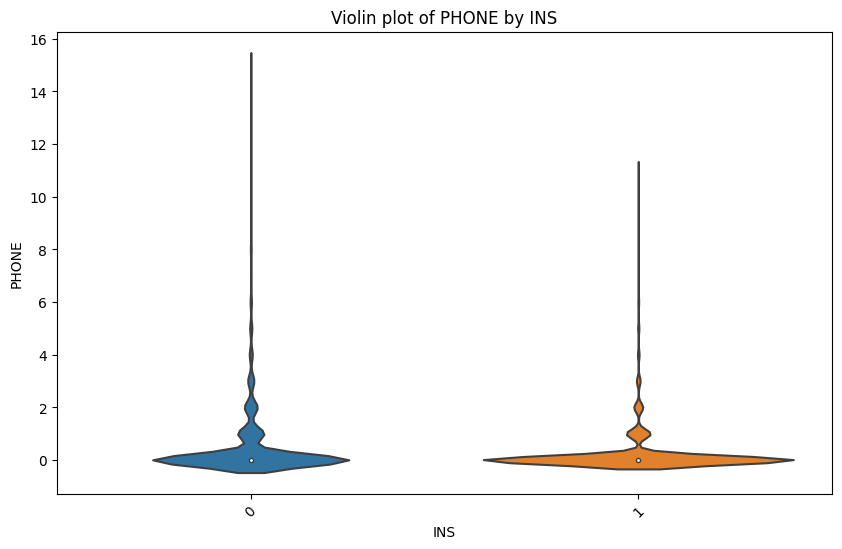

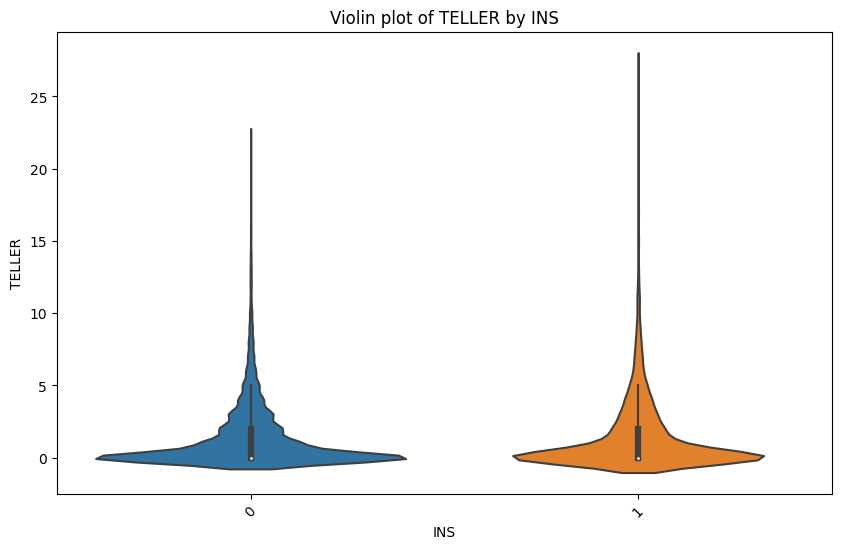

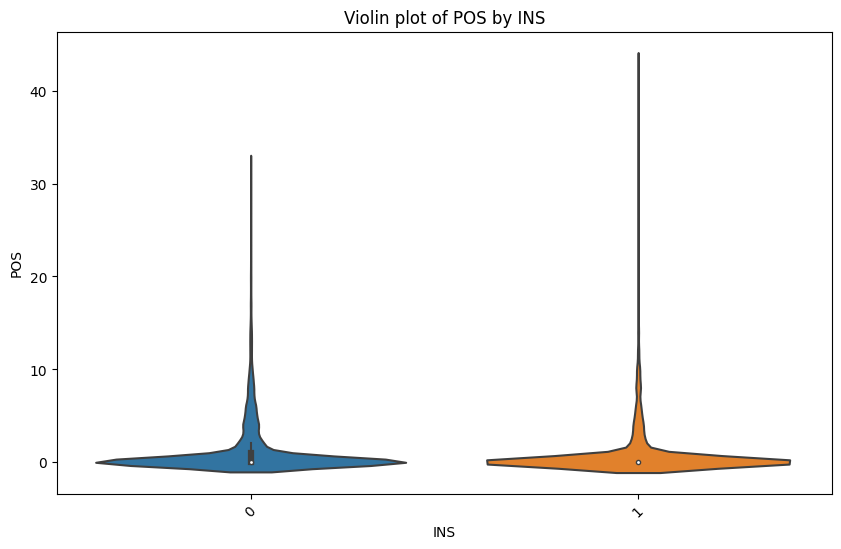

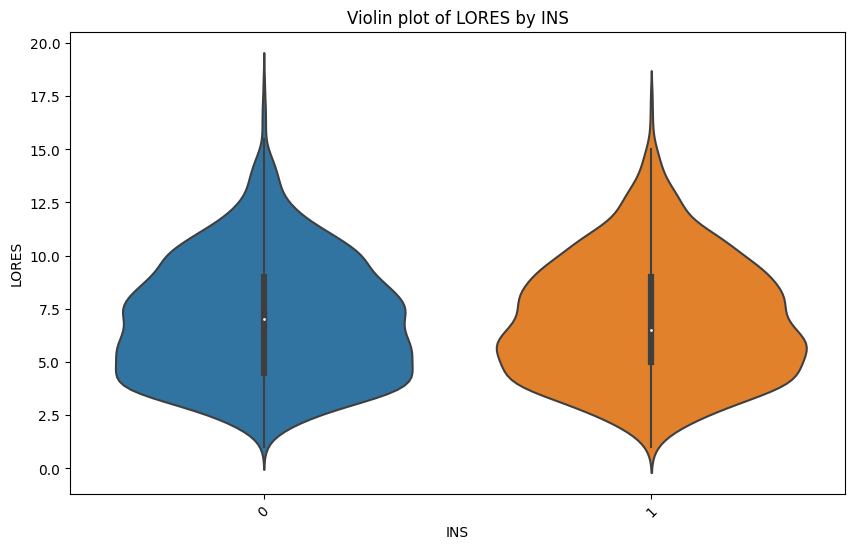

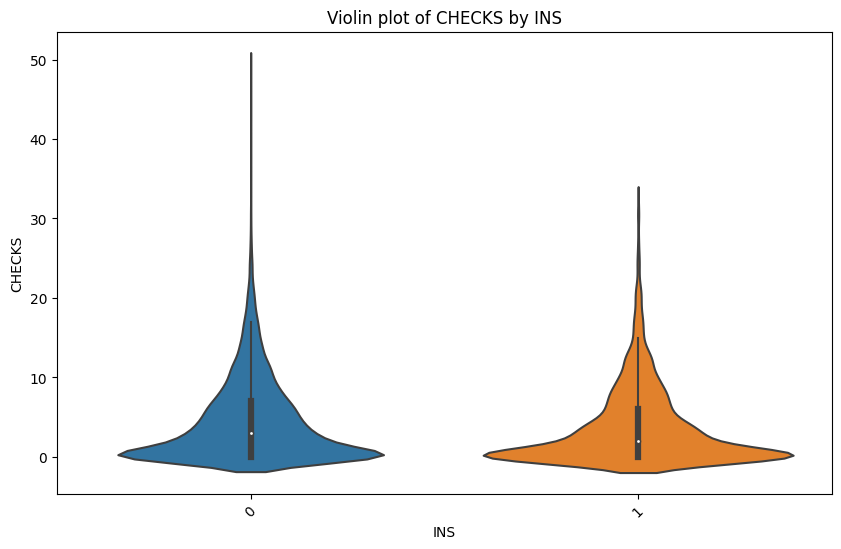

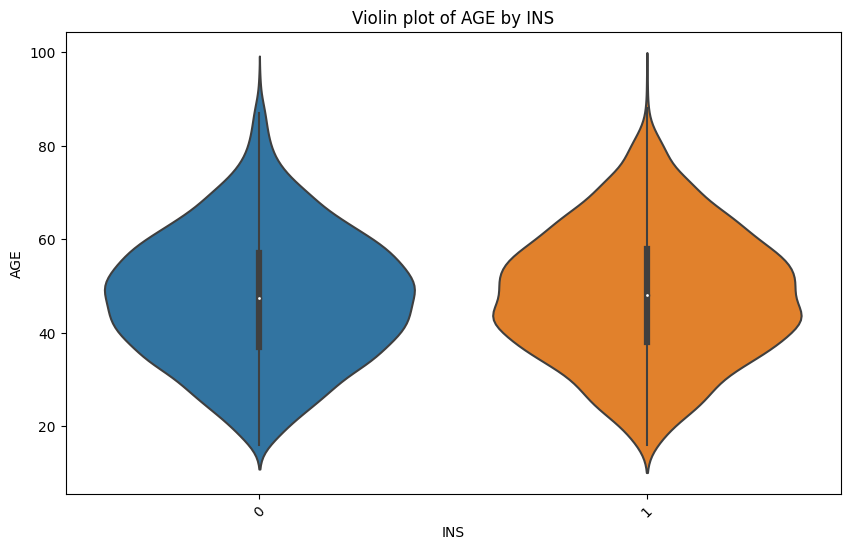

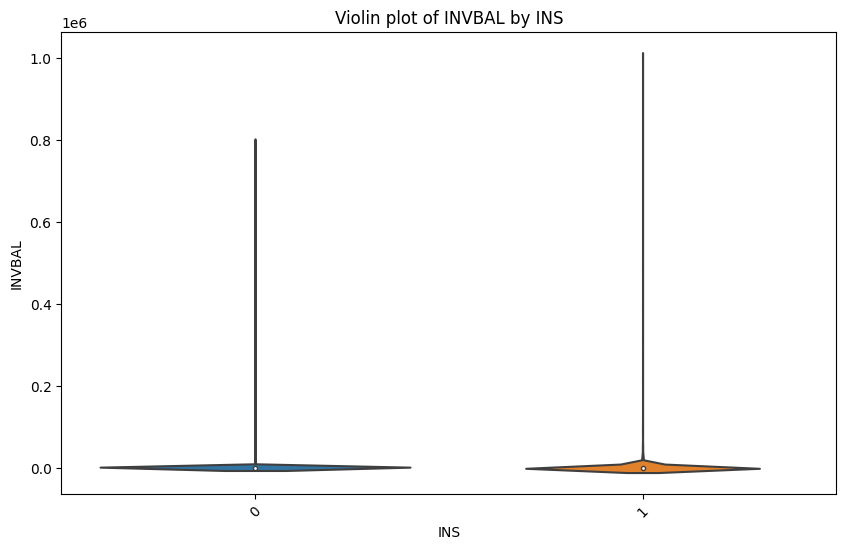

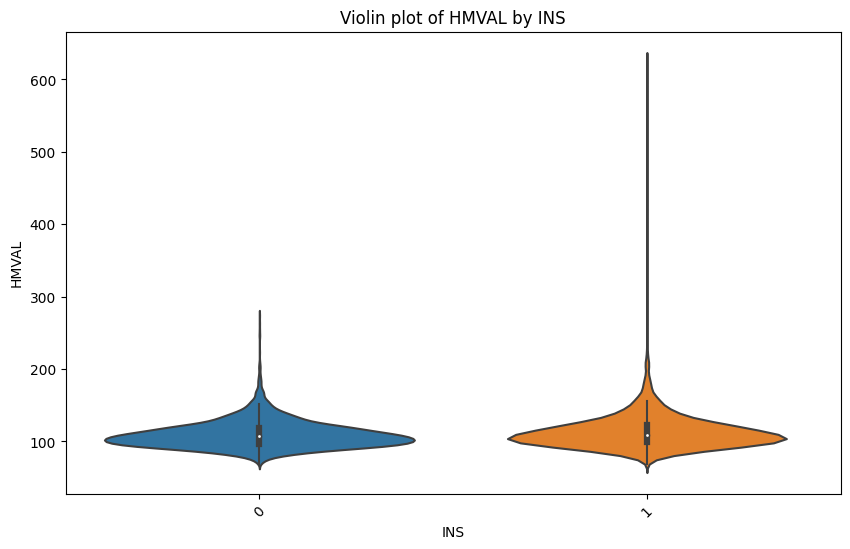

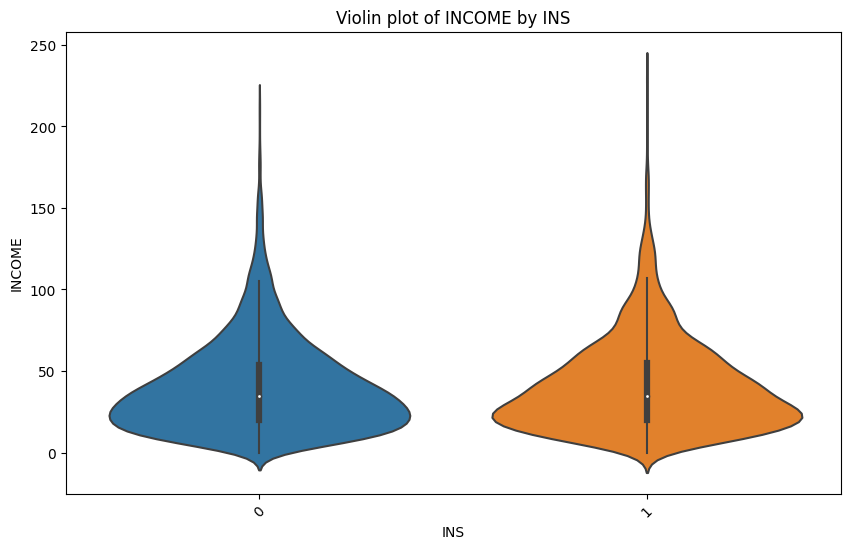

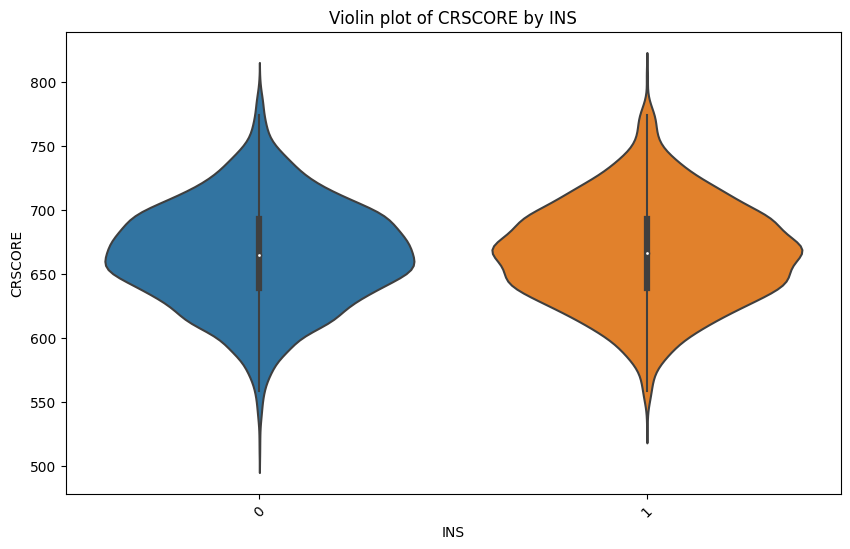

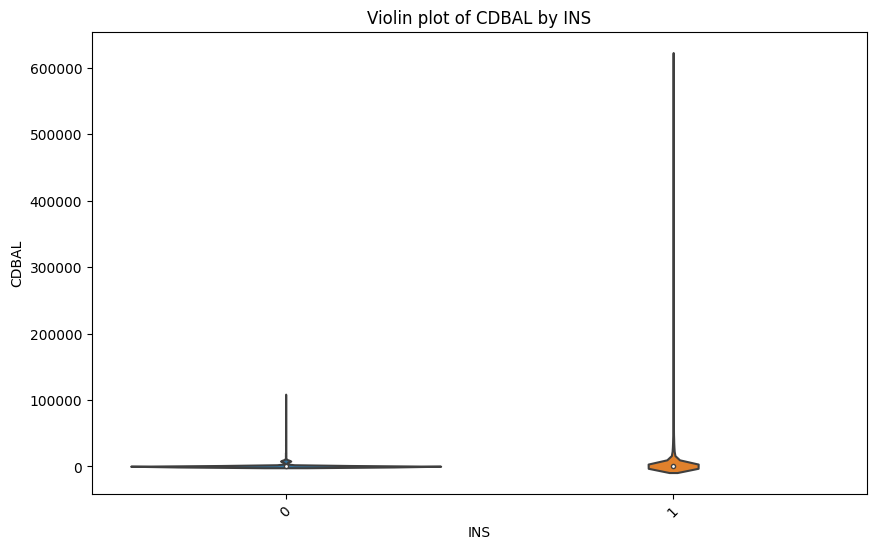

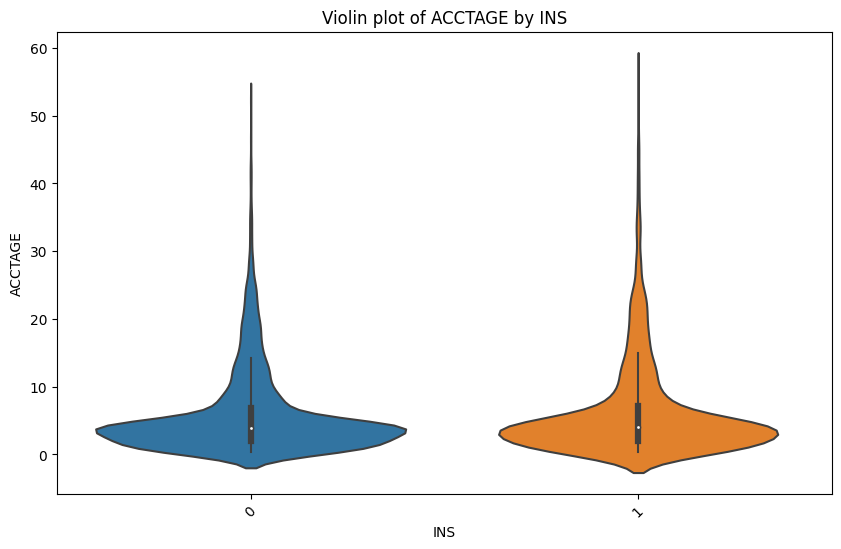

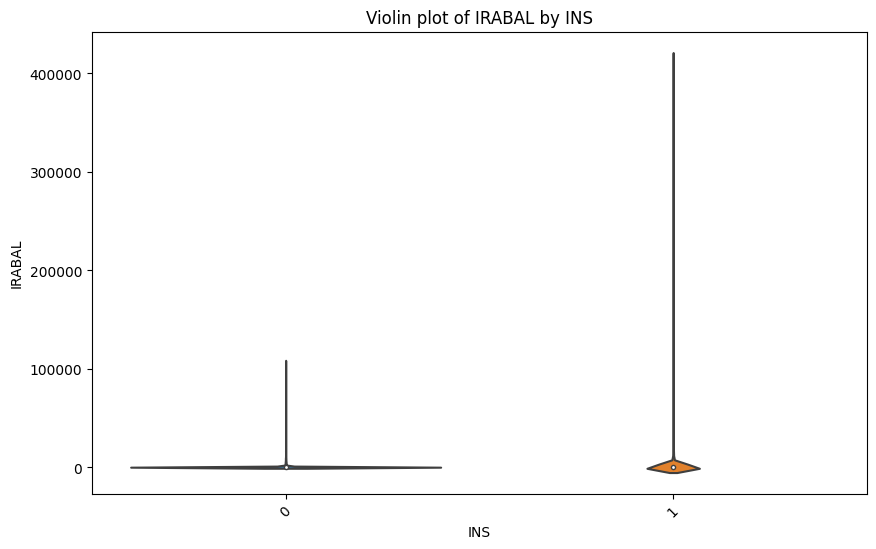

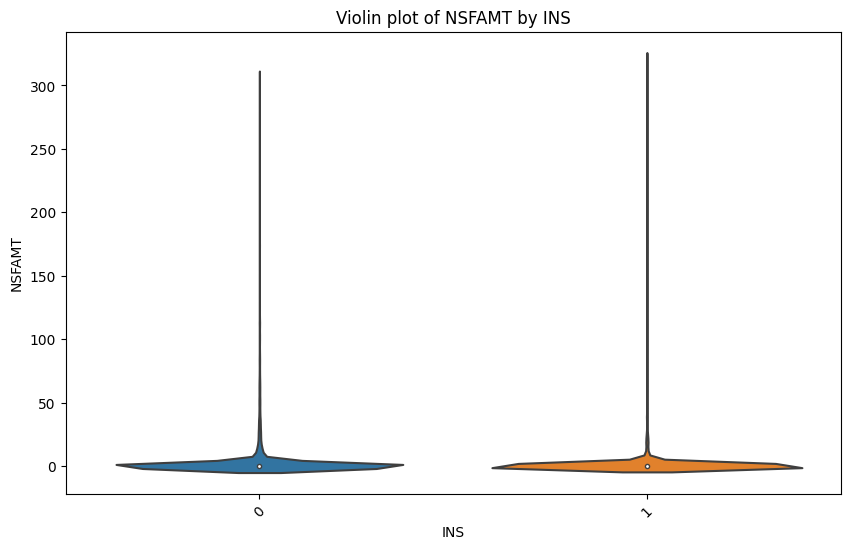

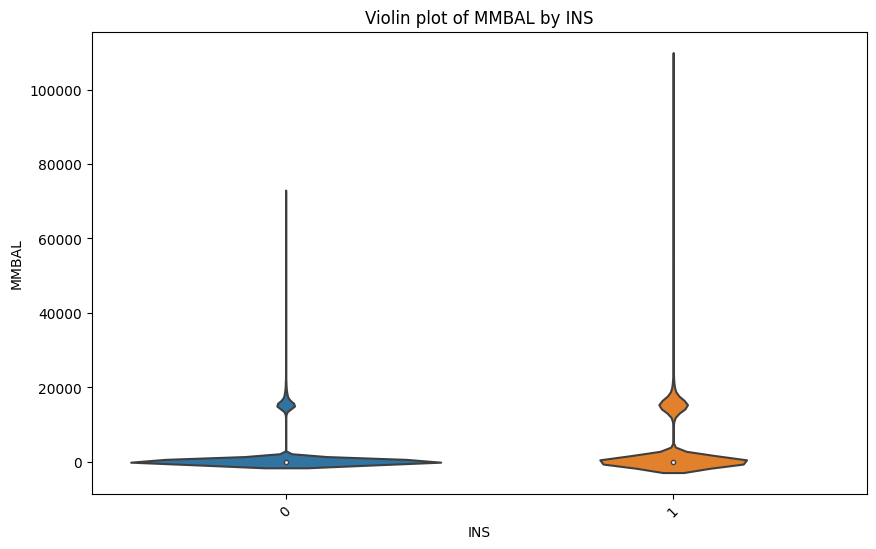

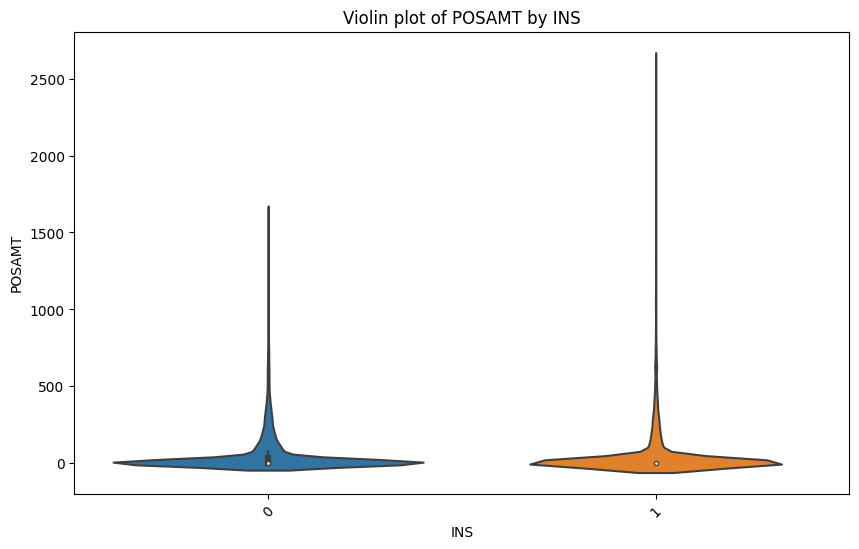

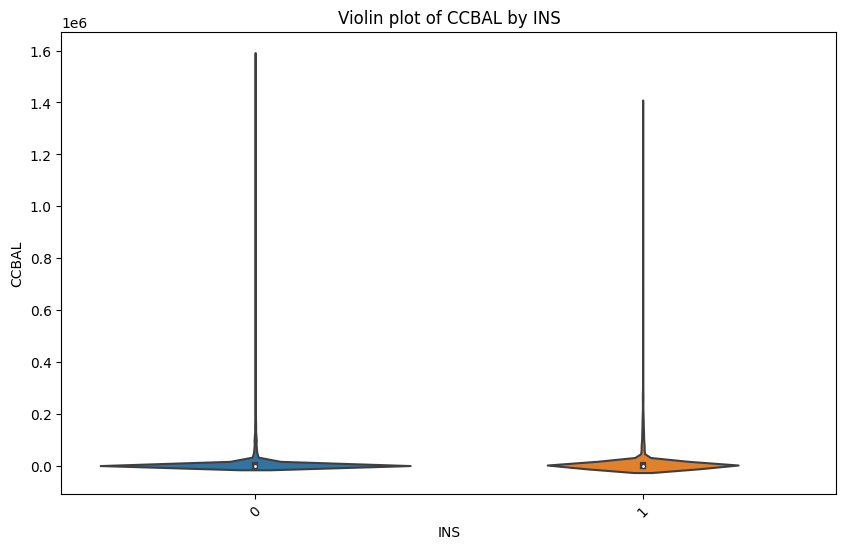

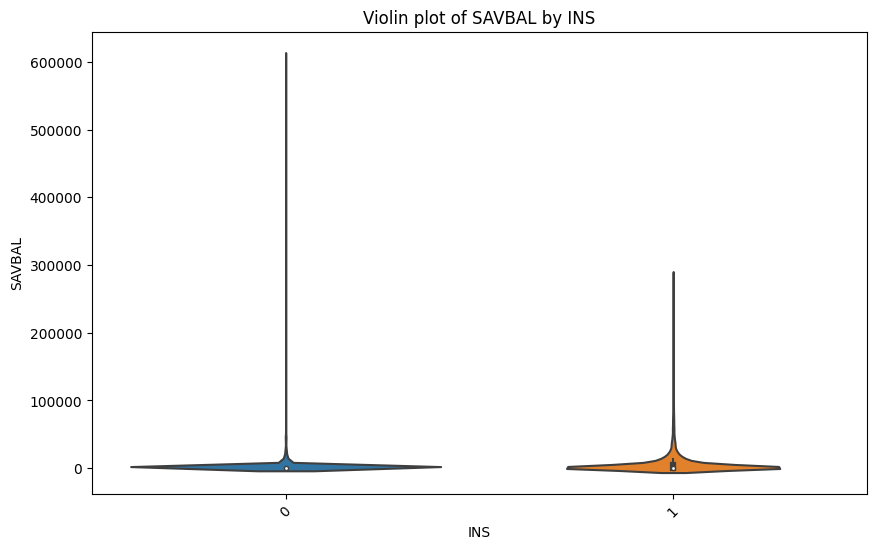

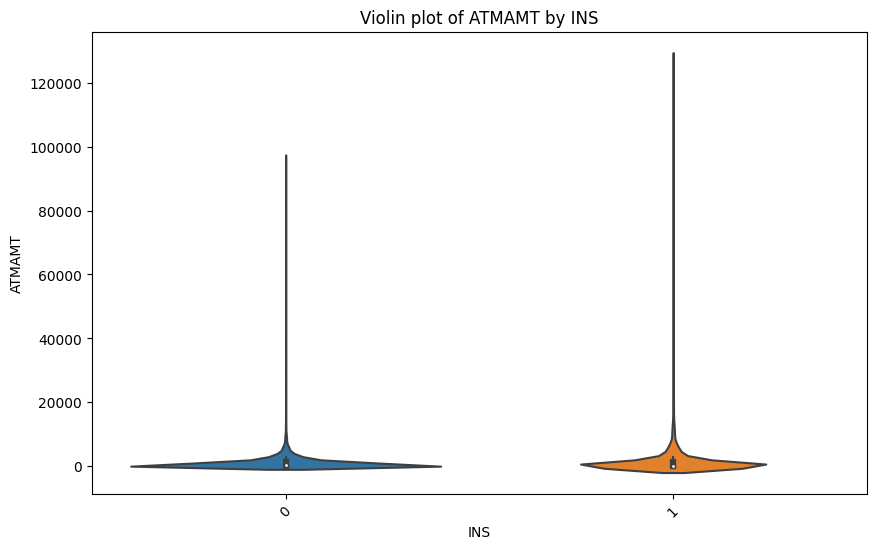

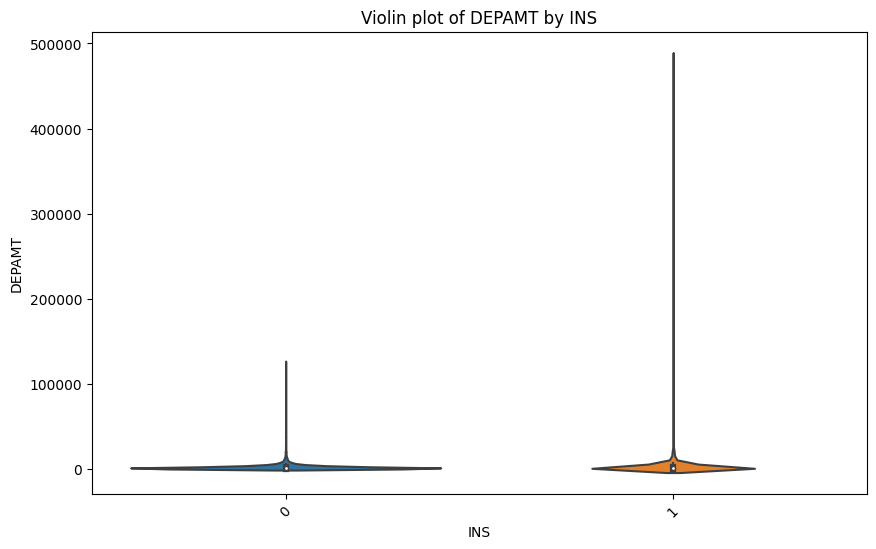

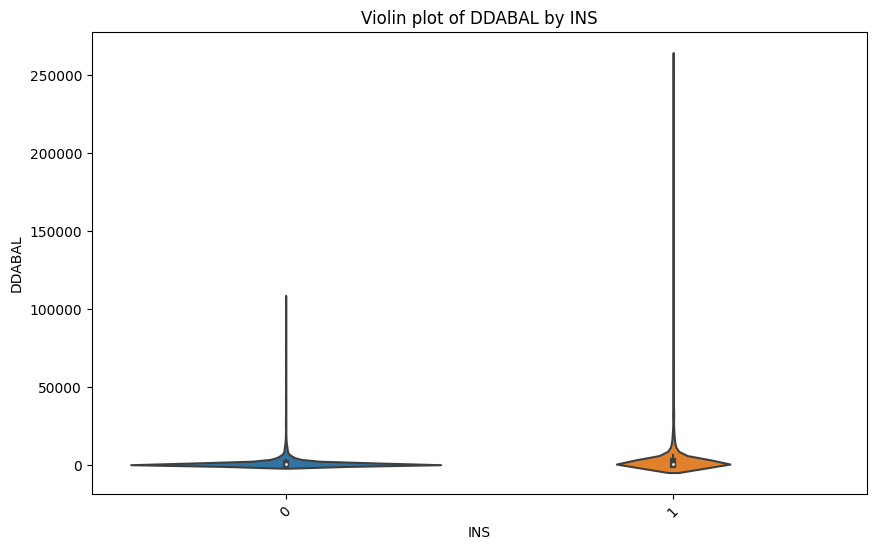

In [9]:
for col in conts:
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='INS', y=col, data=df)
    plt.title(f'Violin plot of {col} by INS')
    plt.xticks(rotation=45)  # Rotate x-axis labels if needed
    plt.show()

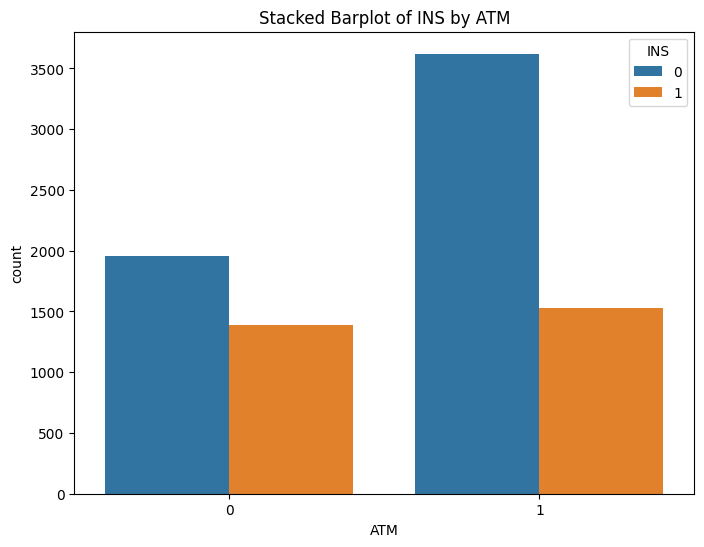

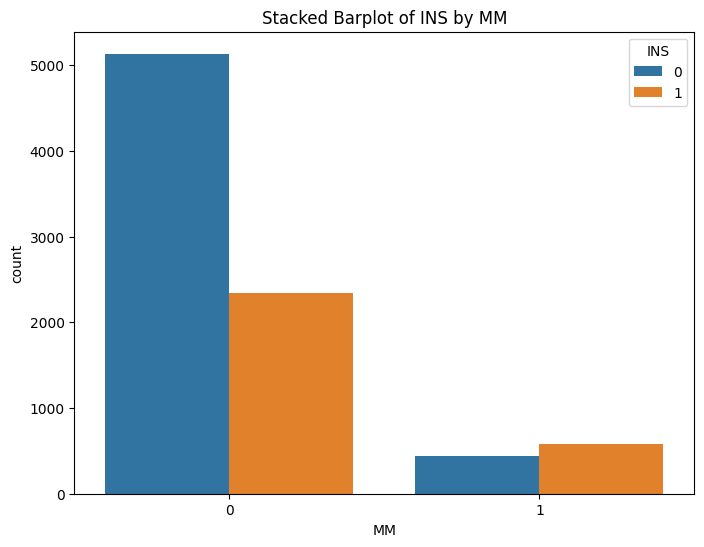

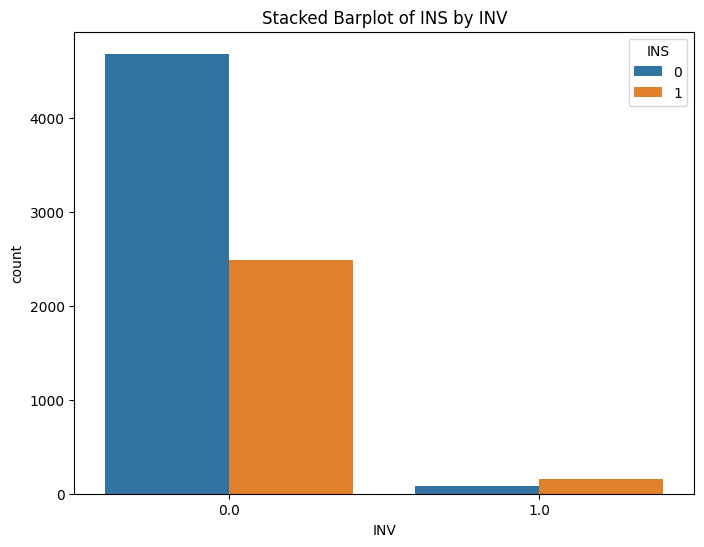

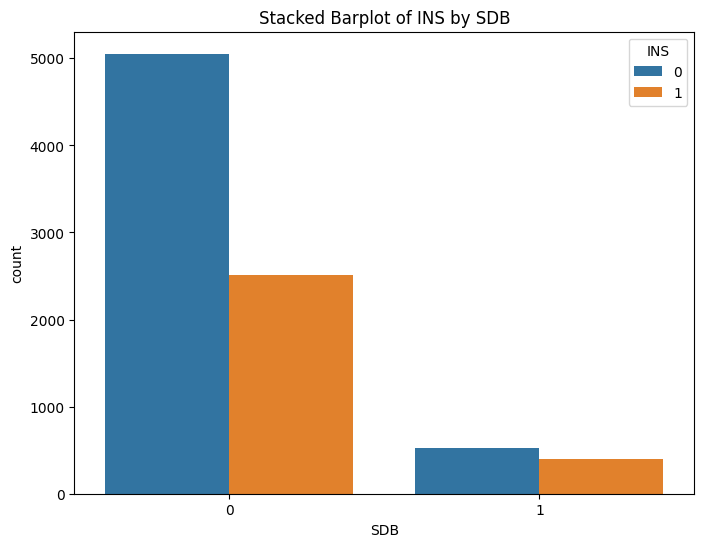

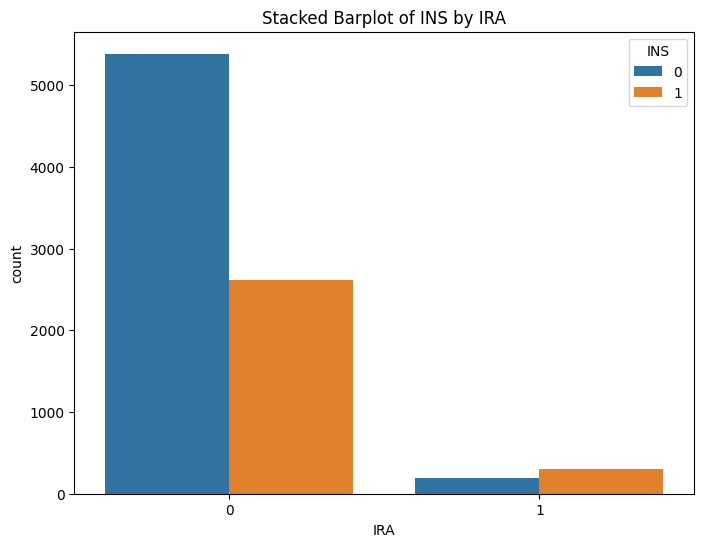

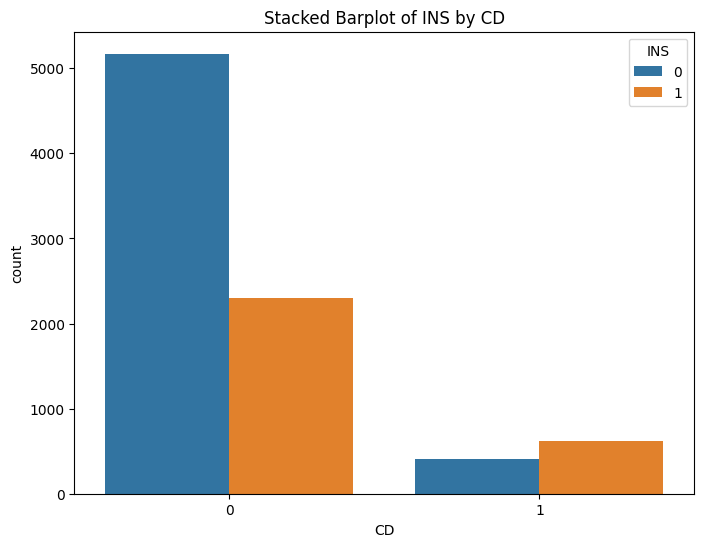

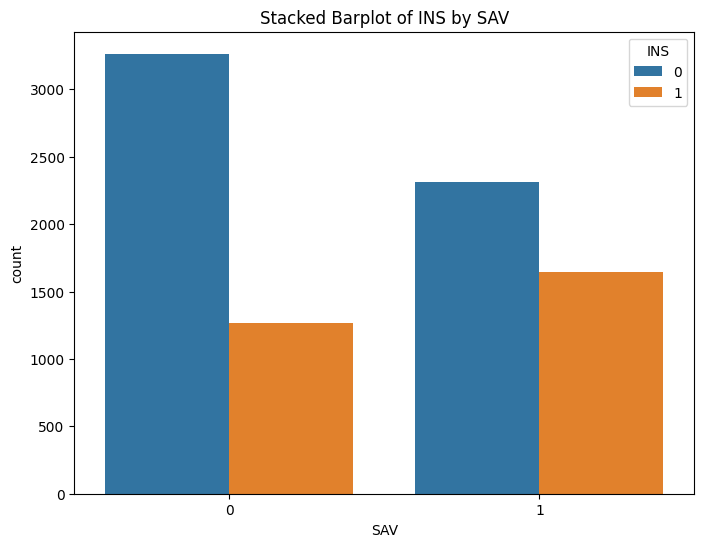

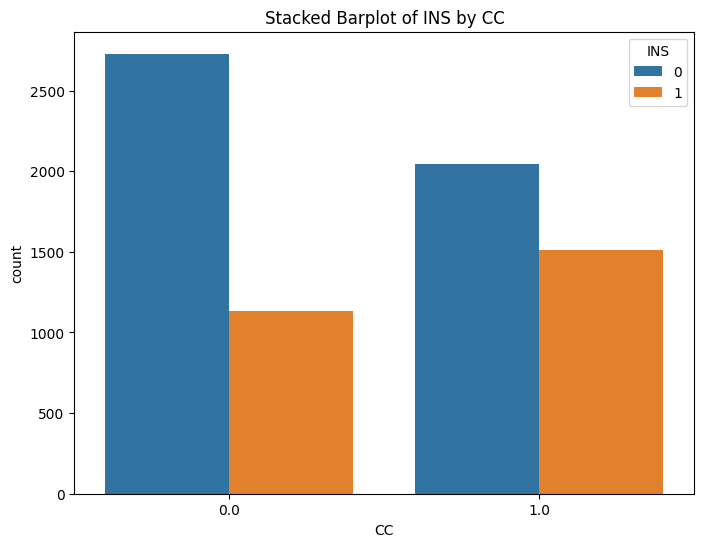

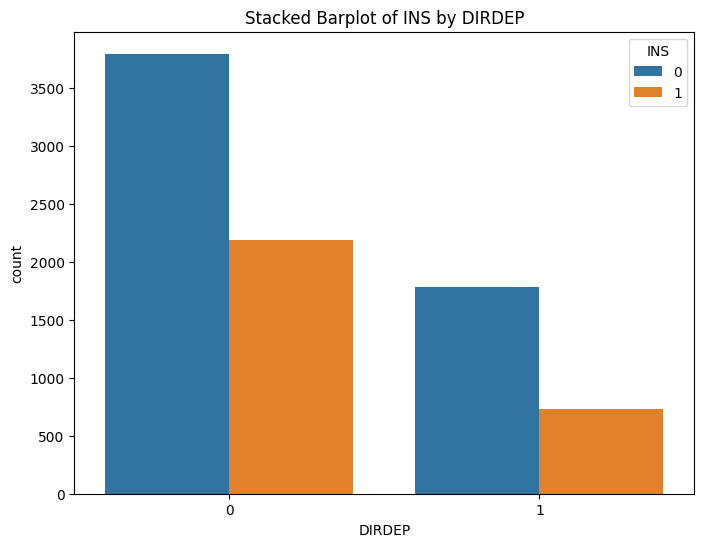

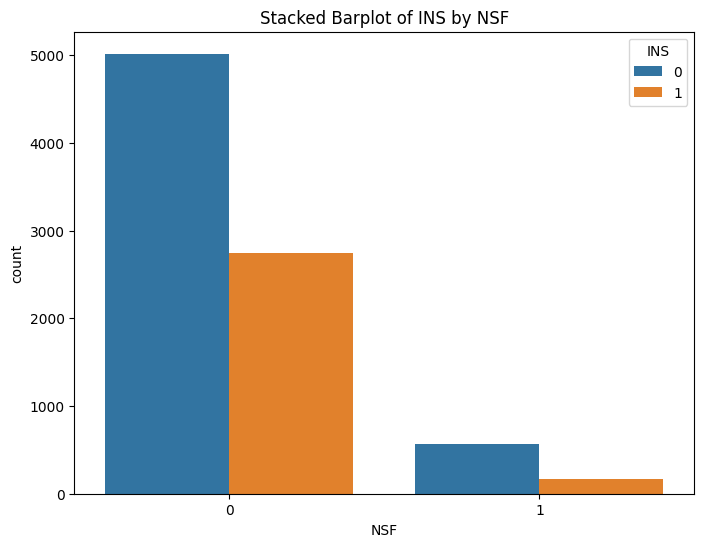

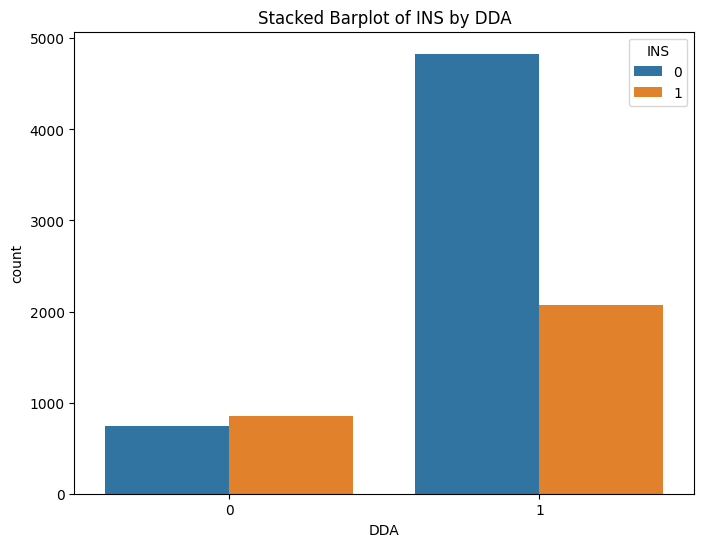

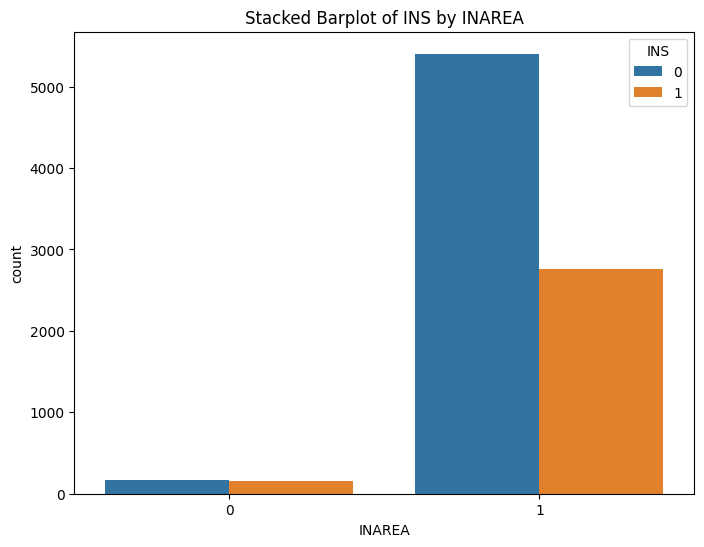

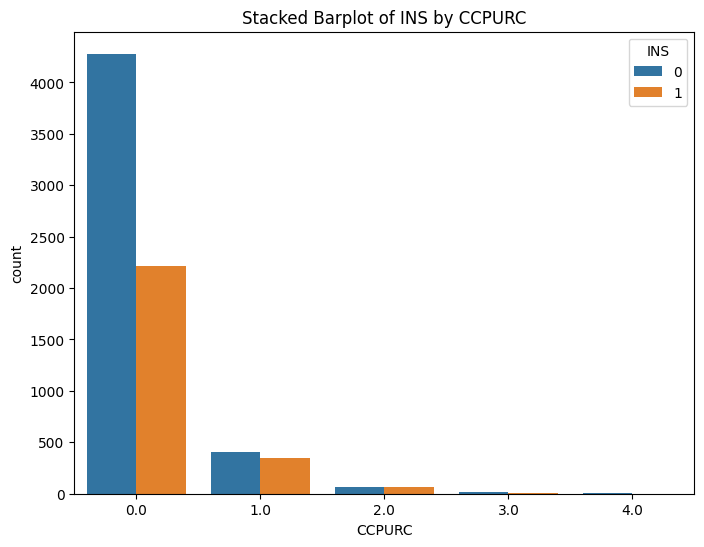

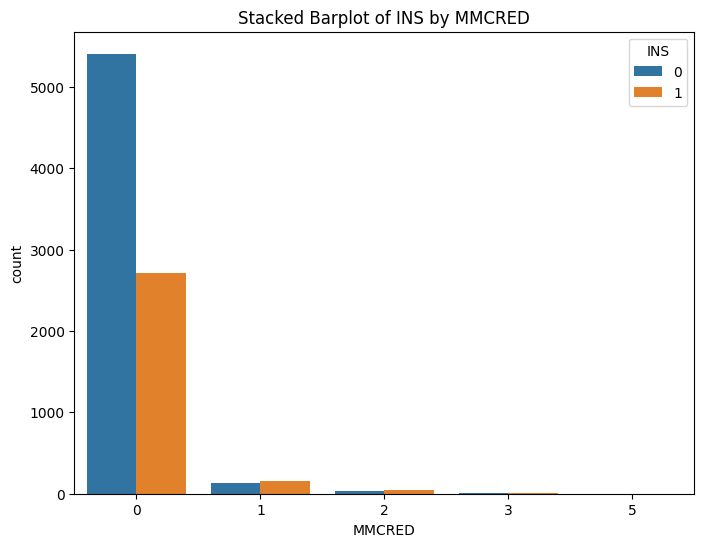

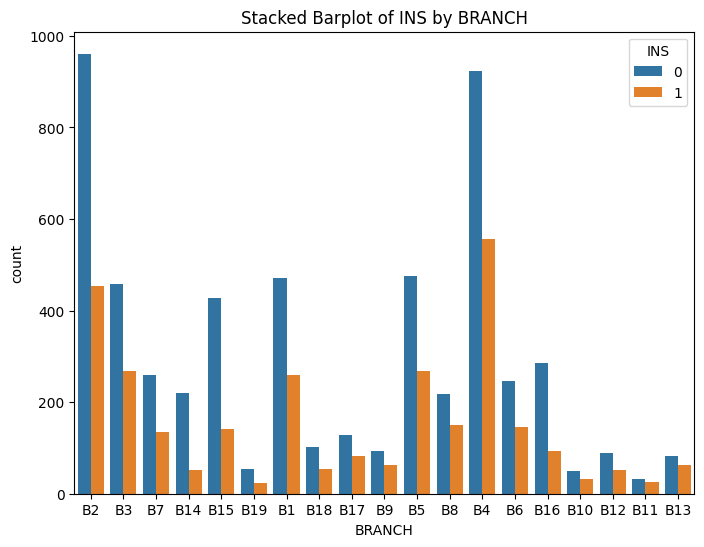

In [10]:
for col in cats:
    plt.figure(figsize=(8,6))
    sns.countplot(x=col, hue="INS", data=df)
    plt.title(f"Stacked Barplot of INS by {col}")
    plt.show()

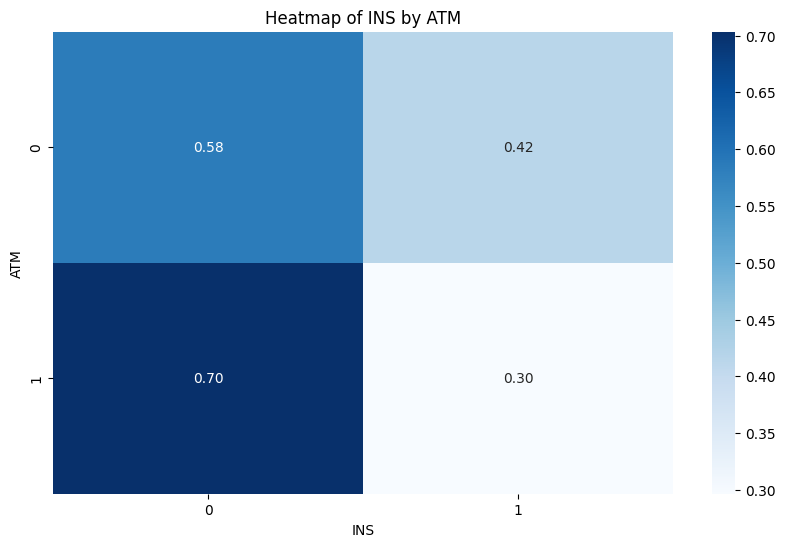

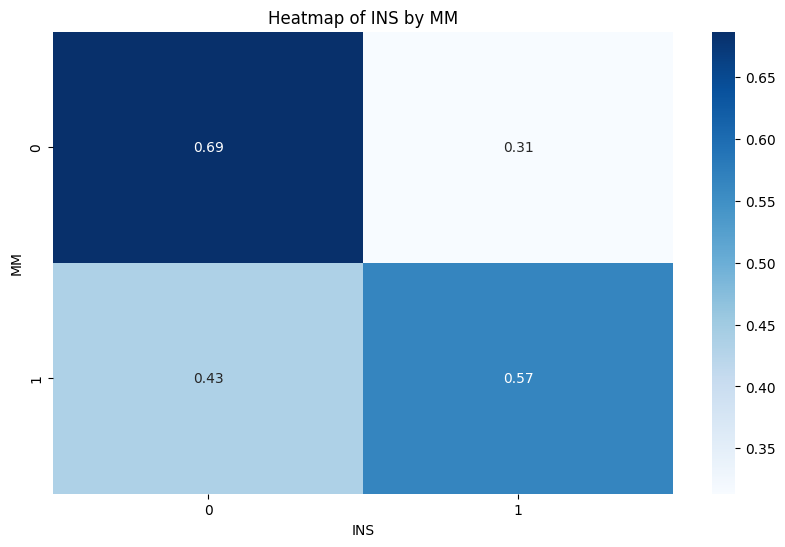

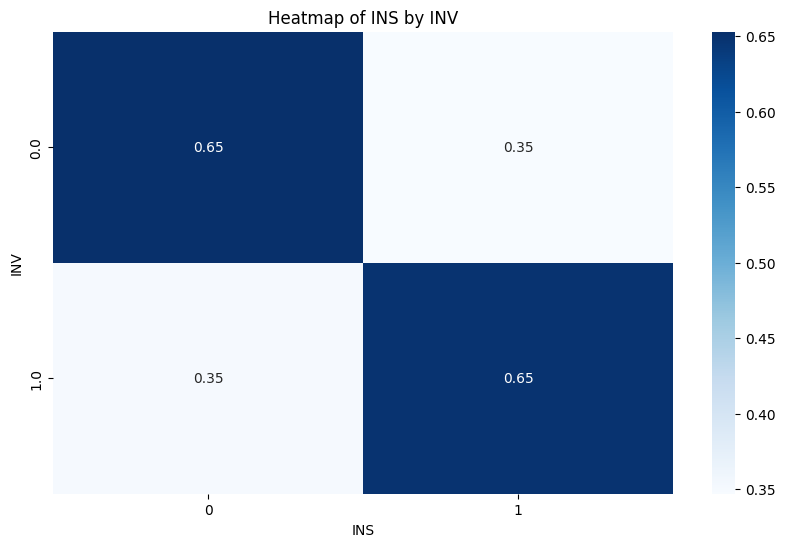

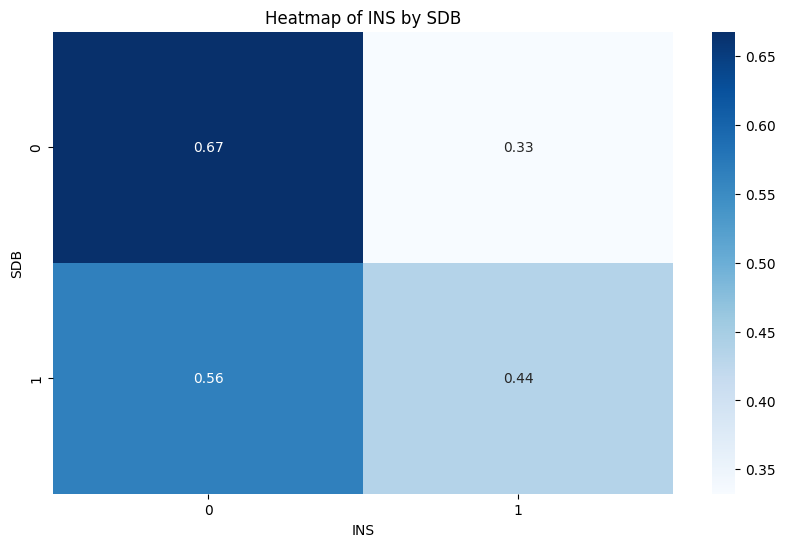

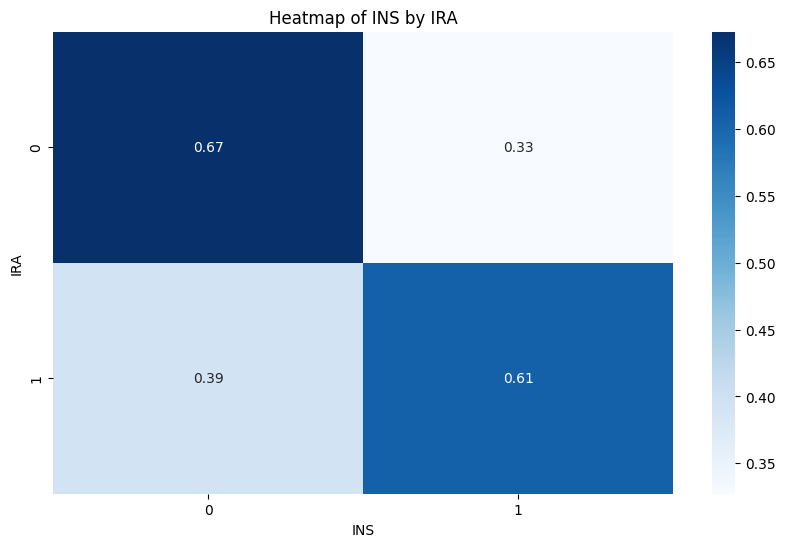

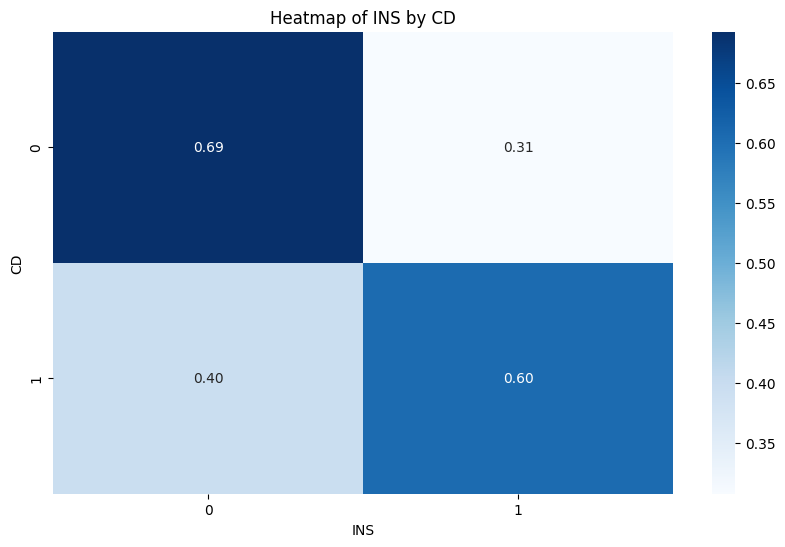

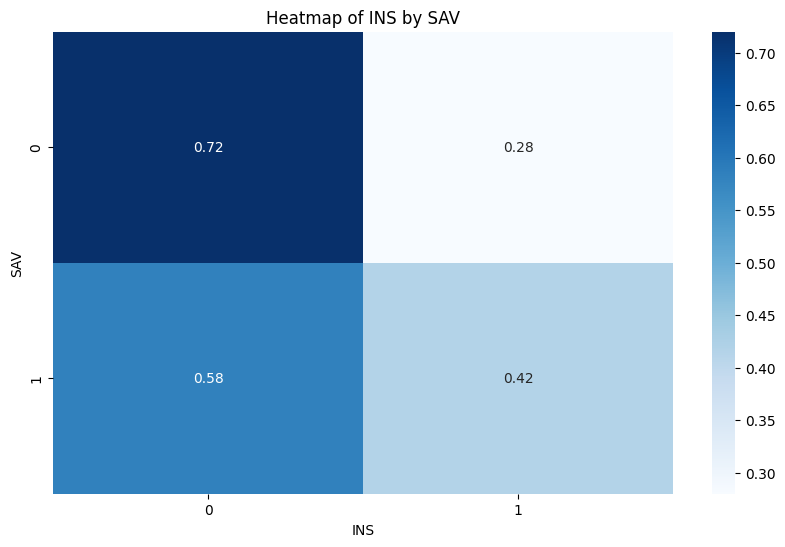

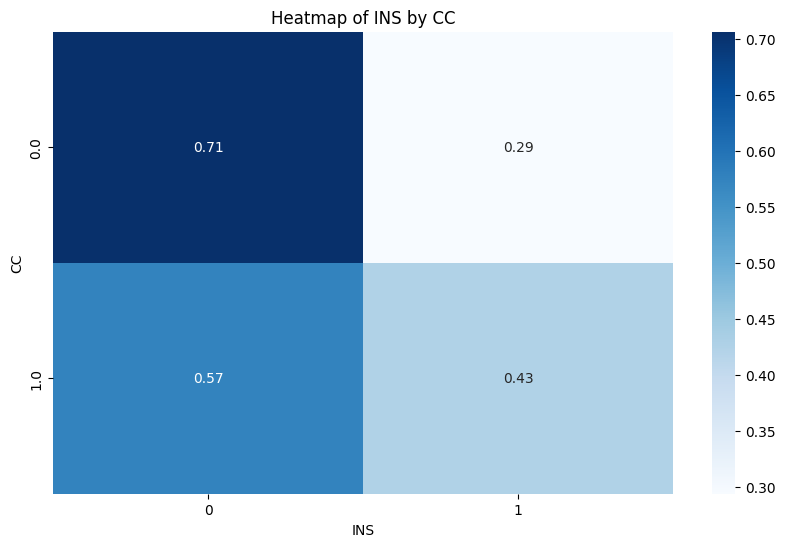

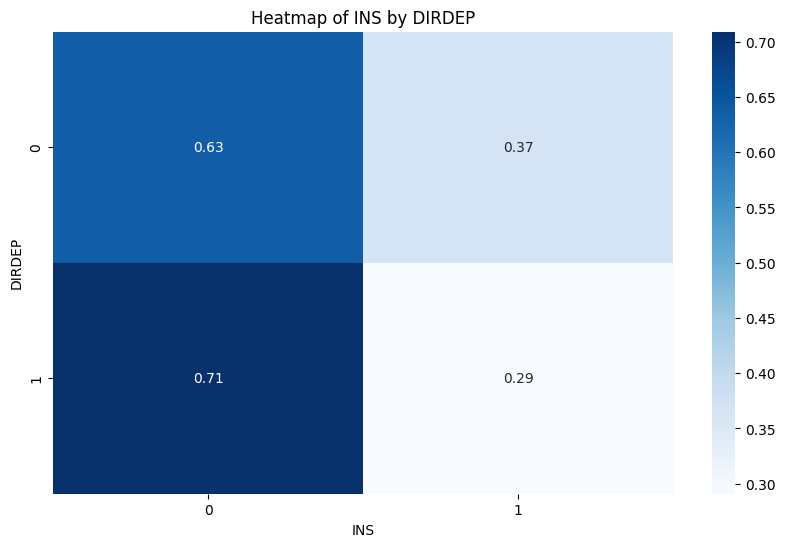

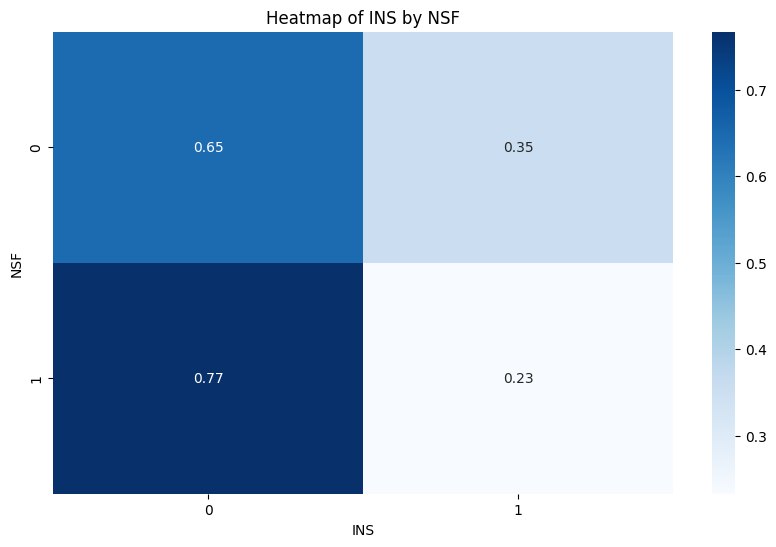

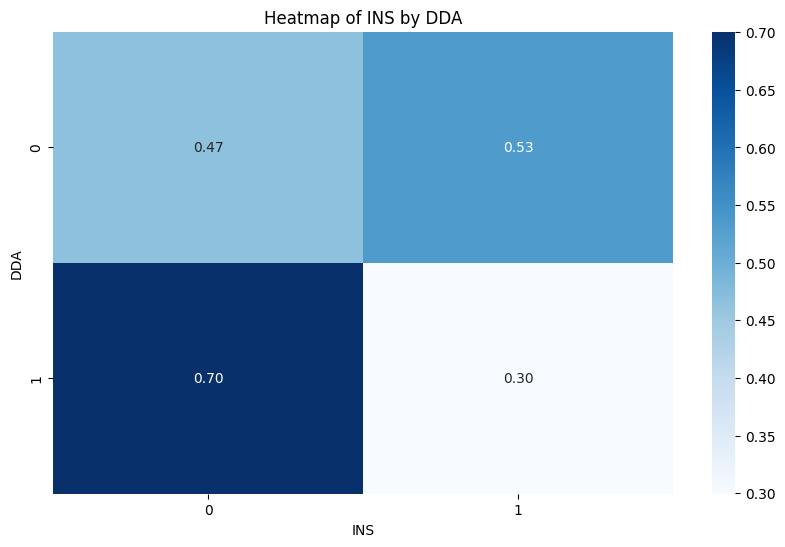

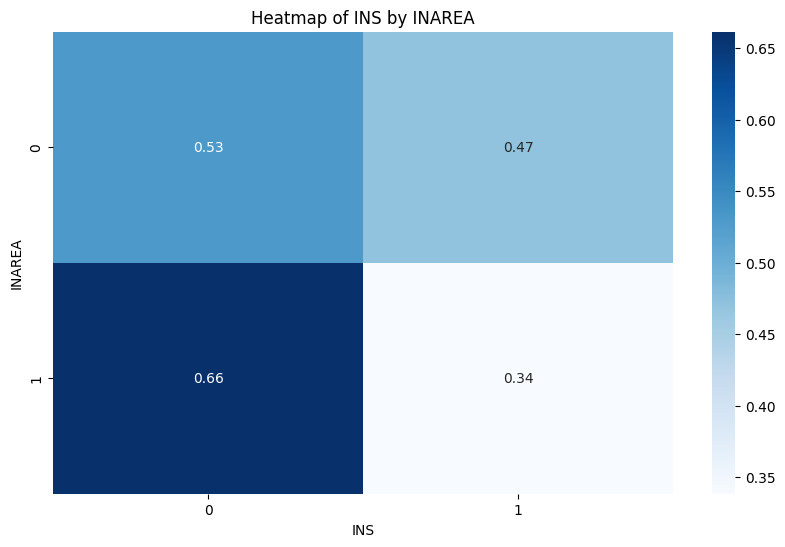

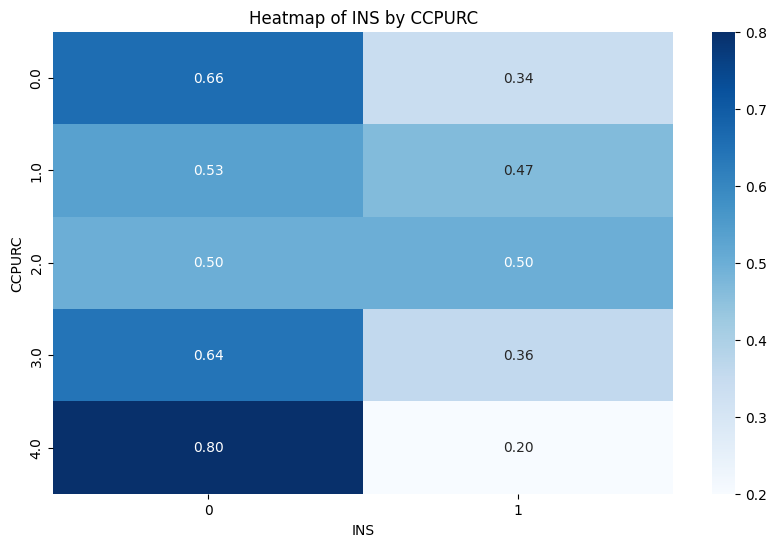

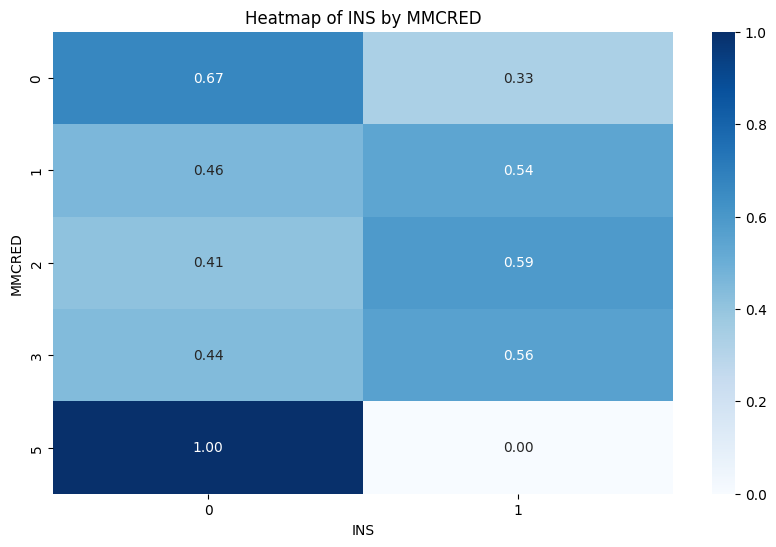

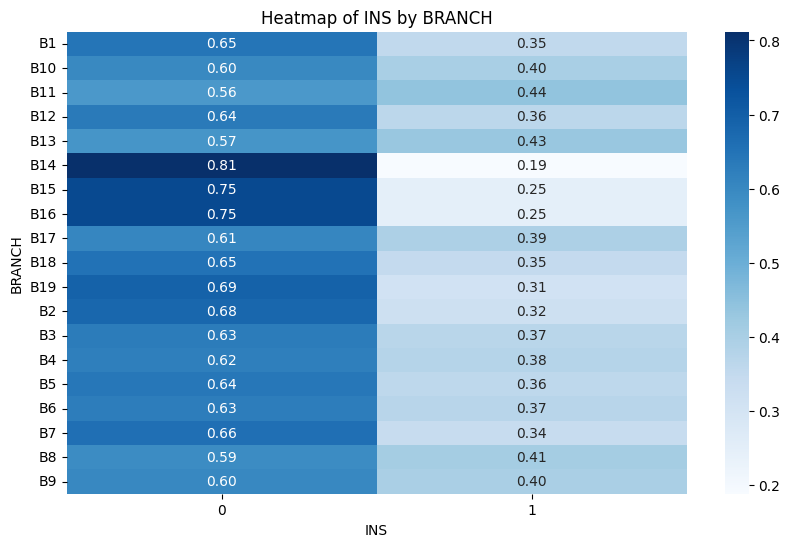

In [11]:
# Loop through each categorical predictor
for col in cats:
    crosstab = pd.crosstab(df[col], df['INS'], normalize='index')  # Normalizes by row
    plt.figure(figsize=(10, 6))
    sns.heatmap(crosstab, annot=True, cmap='Blues', fmt=".2f")
    plt.title(f'Heatmap of INS by {col}')
    plt.xlabel('INS')
    plt.ylabel(col)
    plt.show()

#### Null Handling: 
- need to fill cat nulls with mode
- need to fill cont nulls with median

In [9]:
for col in conts:
    df[col].fillna(df[col].median(), inplace=True)

for col in cats:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isna().mean()

ACCTAGE    0.0
DDA        0.0
DDABAL     0.0
DEP        0.0
DEPAMT     0.0
CHECKS     0.0
DIRDEP     0.0
NSF        0.0
NSFAMT     0.0
PHONE      0.0
TELLER     0.0
SAV        0.0
SAVBAL     0.0
ATM        0.0
ATMAMT     0.0
POS        0.0
POSAMT     0.0
CD         0.0
CDBAL      0.0
IRA        0.0
IRABAL     0.0
INV        0.0
INVBAL     0.0
MM         0.0
MMBAL      0.0
MMCRED     0.0
CC         0.0
CCBAL      0.0
CCPURC     0.0
SDB        0.0
INCOME     0.0
LORES      0.0
HMVAL      0.0
AGE        0.0
CRSCORE    0.0
INAREA     0.0
INS        0.0
BRANCH     0.0
dtype: float64

In [10]:
df.head()

,ACCTAGE,DDA,DDABAL,DEP,DEPAMT,CHECKS,DIRDEP,NSF,NSFAMT,PHONE,...,CCPURC,SDB,INCOME,LORES,HMVAL,AGE,CRSCORE,INAREA,INS,BRANCH
0,0.7,1,1986.81,1,446.93,1,1,0,0.00,0.0,...,1.0,0,4.0,7.0,87.0,51.0,674.0,1,0,B2
1,4.1,0,0.00,0,0.00,0,0,0,0.00,0.0,...,0.0,0,30.0,8.5,97.0,60.0,640.0,1,1,B3
2,12.3,1,1069.78,5,6813.58,13,1,0,0.00,2.0,...,0.0,0,19.0,3.0,107.0,55.0,662.0,1,1,B7
3,0.8,1,190.03,3,880.25,1,0,1,5.65,0.0,...,0.0,1,20.0,4.0,107.0,40.0,642.0,1,0,B14
4,1.6,1,257.13,5,3408.35,14,0,1,60.25,0.0,...,0.0,0,24.0,8.5,95.0,54.0,732.0,1,0,B15


In [11]:
df.shape

(8495, 38)

#### A. Homework 1

##### 1. Assignment: Build a GAM with Splines
• The Bank is also interested in the value of the GAM approach to model building.
- Build a GAM model using splines on the continuous variables.
- feature selection the ML way


Feature Selection with a Linear Regression Model
- meeting assumptions is the issue here

In [12]:
train_dummy = pd.get_dummies(df, columns=cats).astype(int)

train_dummy

,ACCTAGE,DDABAL,DEP,DEPAMT,CHECKS,NSFAMT,PHONE,TELLER,SAVBAL,ATMAMT,...,BRANCH_B18,BRANCH_B19,BRANCH_B2,BRANCH_B3,BRANCH_B4,BRANCH_B5,BRANCH_B6,BRANCH_B7,BRANCH_B8,BRANCH_B9
0,0,1986,1,446,1,0,0,0,0,268,...,0,0,1,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,12,1069,5,6813,13,0,2,9,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,190,3,880,1,5,0,0,11,1582,...,0,0,0,0,0,0,0,0,0,0
4,1,257,5,3408,14,60,0,1,9,3807,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8490,10,2262,2,4761,7,7,2,1,0,5822,...,0,0,1,0,0,0,0,0,0,0
8491,6,3683,2,3271,13,0,0,0,0,1540,...,0,0,1,0,0,0,0,0,0,0
8492,8,46593,3,55203,9,0,0,11,0,0,...,0,0,0,1,0,0,0,0,0,0
8493,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
train_dummy.columns

Index(['ACCTAGE', 'DDABAL', 'DEP', 'DEPAMT', 'CHECKS', 'NSFAMT', 'PHONE',
       'TELLER', 'SAVBAL', 'ATMAMT', 'POS', 'POSAMT', 'CDBAL', 'IRABAL',
       'INVBAL', 'MMBAL', 'CCBAL', 'INCOME', 'LORES', 'HMVAL', 'AGE',
       'CRSCORE', 'INS', 'ATM_0', 'ATM_1', 'MM_0', 'MM_1', 'INV_0.0',
       'INV_1.0', 'SDB_0', 'SDB_1', 'IRA_0', 'IRA_1', 'CD_0', 'CD_1', 'SAV_0',
       'SAV_1', 'CC_0.0', 'CC_1.0', 'DIRDEP_0', 'DIRDEP_1', 'NSF_0', 'NSF_1',
       'DDA_0', 'DDA_1', 'INAREA_0', 'INAREA_1', 'CCPURC_0.0', 'CCPURC_1.0',
       'CCPURC_2.0', 'CCPURC_3.0', 'CCPURC_4.0', 'MMCRED_0', 'MMCRED_1',
       'MMCRED_2', 'MMCRED_3', 'MMCRED_5', 'BRANCH_B1', 'BRANCH_B10',
       'BRANCH_B11', 'BRANCH_B12', 'BRANCH_B13', 'BRANCH_B14', 'BRANCH_B15',
       'BRANCH_B16', 'BRANCH_B17', 'BRANCH_B18', 'BRANCH_B19', 'BRANCH_B2',
       'BRANCH_B3', 'BRANCH_B4', 'BRANCH_B5', 'BRANCH_B6', 'BRANCH_B7',
       'BRANCH_B8', 'BRANCH_B9'],
      dtype='object')

In [14]:
train_dummy.rename(columns={'INV_0.0' : 'INV_0','INV_1.0':'INV_1', 'CC_0.0': 'CC_0', 'CC_1.0': 'CC_1', 'CCPURC_0.0':'CCPURC_0', 'CCPURC_1.0':'CCPURC_1',
                                    'CCPURC_2.0':'CCPURC_2', 'CCPURC_3.0':'CCPURC_3', 'CCPURC_4.0':'CCPURC_4'}, inplace=True)

In [15]:
X_train = train_dummy.loc[:, train_dummy.columns != "INS"]

y_train = train_dummy["INS"]

In [19]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

lm = LinearRegression()

model_cv = SequentialFeatureSelector(lm, n_features_to_select = "auto", direction = "backward", scoring = "neg_mean_squared_error", cv = 10)

model_cv.fit(X_train, y_train)

SequentialFeatureSelector(cv=10, direction='backward',
                          estimator=LinearRegression(),
                          scoring='neg_mean_squared_error')

In [20]:
model_cv.get_feature_names_out()

array(['ACCTAGE', 'DDABAL', 'DEP', 'CHECKS', 'PHONE', 'TELLER', 'SAVBAL',
       'ATMAMT', 'POS', 'POSAMT', 'CDBAL', 'IRABAL', 'ATM_0', 'ATM_1',
       'MM_0', 'MM_1', 'INV_0', 'INV_1', 'SDB_0', 'SDB_1', 'IRA_0',
       'CD_0', 'CD_1', 'SAV_0', 'SAV_1', 'CC_0', 'DIRDEP_0', 'DIRDEP_1',
       'DDA_0', 'DDA_1', 'CCPURC_0', 'CCPURC_1', 'CCPURC_4', 'MMCRED_5',
       'BRANCH_B14', 'BRANCH_B15', 'BRANCH_B16', 'BRANCH_B2'],
      dtype=object)

Feature Selection with a Regularized Regression - Elastic Net, Using Cross Validation

In [21]:
from sklearn.linear_model import ElasticNetCV

en_model = ElasticNetCV(cv = 10, l1_ratio = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], n_alphas = 100)

en_model.fit(X_train, y_train)

ElasticNetCV(cv=10, l1_ratio=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [12]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Standardize your features and apply ElasticNetCV
elastic_net = Pipeline([
    ('scaler', StandardScaler()),  # Elastic Net benefits from feature scaling
    ('elasticnet', ElasticNetCV(cv=5, l1_ratio=[0.5, 0.7, 0.9, 1.0], alphas=[0.1, 1.0, 10.0]))
])

# Fit Elastic Net to the data
elastic_net.fit(X_train, y_train)

# Get selected features (non-zero coefficients)
selected_features = X_train.columns[(elastic_net.named_steps['elasticnet'].coef_ != 0)]
print("Selected Features:", selected_features)


Selected Features: Index(['DDABAL', 'SAVBAL', 'MM_0', 'MM_1', 'IRA_0', 'IRA_1', 'CD_0', 'CD_1',
       'SAV_0', 'SAV_1', 'CC_0', 'CC_1', 'DDA_0', 'DDA_1'],
      dtype='object')


In [23]:
# regularization value
optimal_alpha = elastic_net.named_steps['elasticnet'].alpha_
optimal_alpha

0.1

In [24]:
# balance between ridge and lasso
optimal_l1_ratio = elastic_net.named_steps['elasticnet'].l1_ratio_
optimal_l1_ratio

0.5

Build the GAM with a Smoothing Spline

In [25]:
pip install pygam

Note: you may need to restart the kernel to use updated packages.


In [26]:
import statsmodels as sm
from statsmodels.gam.api import GLMGam, BSplines

In [16]:
# Specify the continuous and categorical columns

continuous_vars = ["TELLER", "CHECKS", "CDBAL", "ACCTAGE", "MMBAL", "CCBAL", "SAVBAL", "ATMAMT", "DDABAL", "DEP"]
categorical_vars = ["DDA", "NSF", "CD", "IRA", "INV", "CC", "BRANCH",
                    'MM_0', 'MM_1', 'IRA_0', 'IRA_1', 'CD_0', 'CD_1', 
                    'SAV_0', 'SAV_1', 'CC_0', 'CC_1', 'DDA_0', 'DDA_1']


In [28]:

# Only include categorical variables in the main design matrix for X_train and X_test
X_train_categorical = X_train[categorical_vars]
X_test_categorical = X_test[categorical_vars]

# Create the spline basis only for the continuous variables
bs_train = BSplines(X_train[continuous_vars], df=[best_df, best_df], degree=[degree, degree])
bs_test = BSplines(X_test[continuous_vars], df=[best_df, best_df], degree=[degree, degree])

# Define the formula without the continuous variables as they are handled by the spline basis
formula = "INS ~ " + " + ".join(categorical_vars)

# Fit the GAM model using only categorical variables in the formula and the spline basis for continuous variables
gam = GLMGam.from_formula(formula, data=train_dummy.loc[X_train.index], smoother=bs_train).fit()

# Predict with only categorical variables and the test smoother basis
y_pred_proba = gam.predict(exog=X_test_categorical, exog_smooth=bs_test.basis)

# Calculate AUC and ROC as before
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC: {auc}")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'GAM (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


KeyError: "['DDA', 'NSF', 'CD', 'IRA', 'INV', 'CC', 'BRANCH'] not in index"

In [ ]:

# Identify the best model
best_score_index = np.argmin(scores)  # Minimize MSE
best_gam = models[best_score_index]
best_df = df_values[best_score_index]

print(f"Best Degrees of Freedom: {best_df}, Best Mean Squared Error Score: {scores[best_score_index]}")

# Summary of the best GAM model
best_gam.summary()

Best Degrees of Freedom: 4, Best Mean Squared Error Score: 0.21009257916611865


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    INS   No. Observations:                 6796
Model:                         GLMGam   Df Residuals:                     6783
Model Family:                Gaussian   Df Model:                        12.00
Link Function:               Identity   Scale:                         0.18379
Method:                         PIRLS   Log-Likelihood:                -3880.5
Date:                Mon, 04 Nov 2024   Deviance:                       1246.7
Time:                        10:39:04   Pearson chi2:                 1.25e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2059
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1313      0.003     37.689      0.000       0.124       0.138
DDABAL      4.778e-07   8.73e-07      0.547      0.584   -1.23e-06    2.19e-06
SAVBAL     -2.213e-06    7.2e-07     -3.073      0.002   -3.62e-06   -8.01e-07
MM_0          -0.0174      0.008     -2.105      0.035      -0.034      -0.001
MM_1           0.1487      0.009     16.067      0.000       0.131       0.167
IRA_0         -0.0045      0.010     -0.438      0.661      -0.025       0.016
IRA_1          0.1358      0.013     10.821      0.000       0.111       0.160
CD_0          -0.0408      0.008     -5.344      0.000      -0.056      -0.026
CD_1           0.1721      0.009     19.561      0.000       0.155       0.189
SAV_0          0.0355      0.006      6.025      0.000       0.024       0.047
SAV_1          0.0958      0.006     15.201      0.000       0.083       0.108
CC_0           0.0284      0.006      5.008      0.000       0.017       0.039
CC_1           0.1029      0.006     18.448      0.000       0.092       0.114
DDA_0          0.1529      0.008     19.834      0.000       0.138       0.168
DDA_1         -0.0216      0.008     -2.860      0.004      -0.036      -0.007
DDABAL_s0      2.0848      0.202     10.300      0.000       1.688       2.482
DDABAL_s1     -2.7520      0.466     -5.911      0.000      -3.665      -1.839
DDABAL_s2      1.1399      0.267      4.271      0.000       0.617       1.663
SAVBAL_s0      2.6766      0.218     12.284      0.000       2.250       3.104
SAVBAL_s1     -2.2206      0.507     -4.379      0.000      -3.214      -1.227
SAVBAL_s2      0.5882      0.302      1.950      0.051      -0.003       1.180
==============================================================================
"""

#### B. Homework 2

In [13]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [17]:
X_train.columns

Index(['ACCTAGE', 'DDABAL', 'DEP', 'DEPAMT', 'CHECKS', 'NSFAMT', 'PHONE',
       'TELLER', 'SAVBAL', 'ATMAMT', 'POS', 'POSAMT', 'CDBAL', 'IRABAL',
       'INVBAL', 'MMBAL', 'CCBAL', 'INCOME', 'LORES', 'HMVAL', 'AGE',
       'CRSCORE', 'ATM_0', 'ATM_1', 'MM_0', 'MM_1', 'INV_0', 'INV_1', 'SDB_0',
       'SDB_1', 'IRA_0', 'IRA_1', 'CD_0', 'CD_1', 'SAV_0', 'SAV_1', 'CC_0',
       'CC_1', 'DIRDEP_0', 'DIRDEP_1', 'NSF_0', 'NSF_1', 'DDA_0', 'DDA_1',
       'INAREA_0', 'INAREA_1', 'CCPURC_0', 'CCPURC_1', 'CCPURC_2', 'CCPURC_3',
       'CCPURC_4', 'MMCRED_0', 'MMCRED_1', 'MMCRED_2', 'MMCRED_3', 'MMCRED_5',
       'BRANCH_B1', 'BRANCH_B10', 'BRANCH_B11', 'BRANCH_B12', 'BRANCH_B13',
       'BRANCH_B14', 'BRANCH_B15', 'BRANCH_B16', 'BRANCH_B17', 'BRANCH_B18',
       'BRANCH_B19', 'BRANCH_B2', 'BRANCH_B3', 'BRANCH_B4', 'BRANCH_B5',
       'BRANCH_B6', 'BRANCH_B7', 'BRANCH_B8', 'BRANCH_B9'],
      dtype='object')

In [18]:
X_train.shape

(8495, 75)

In [19]:
y_train

0       0
1       1
2       1
3       0
4       0
       ..
8490    0
8491    0
8492    0
8493    1
8494    0
Name: INS, Length: 8495, dtype: int64

In [17]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score


xgb_ins = XGBRegressor(n_estimators = 50, #number of trees
                        subsample = 0.5, #stochastic gradient descent
                        random_state = 12345)

xgb_ins.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=12345, ...)

In [18]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# note: needed an XGBClassifier for binry classification, instead of the Regressor we would need for a continuous variable

# Define the parameter grid
params = {
    'objective': ['binary:logistic'],                                # Binary classification task
    'eval_metric': ['logloss'],                                      # Evaluation metric
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],                    # Depth of the tree
    'eta': [0.1, 0.15, 0.2, 0.25, 0.3],                              # Learning rate
    'subsample': [0.25, 0.5, 0.75, 1],                               # Fraction of samples to use
    'colsample_bytree': [0.25, 0.5, 0.75, 1],                        # Fraction of features to use
    'scale_pos_weight': [1],                                         # Balances class weights (useful if target is imbalanced)
    "n_estimators":[10, 25, 50, 100]
}

# Initialize the XGBClassifier model for binary classification
xgb = XGBClassifier()

# Set up the grid search with cross-validation
grid_search = GridSearchCV(estimator=xgb, param_grid=params, cv=10, scoring='roc_auc')

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score found by GridSearchCV
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC score: {grid_search.best_score_}")


Best parameters: {'colsample_bytree': 1, 'eta': 0.1, 'eval_metric': 'logloss', 'max_depth': 4, 'n_estimators': 100, 'objective': 'binary:logistic', 'scale_pos_weight': 1, 'subsample': 0.75}
Best ROC-AUC score: 0.8037991492765837


Feature Importance 

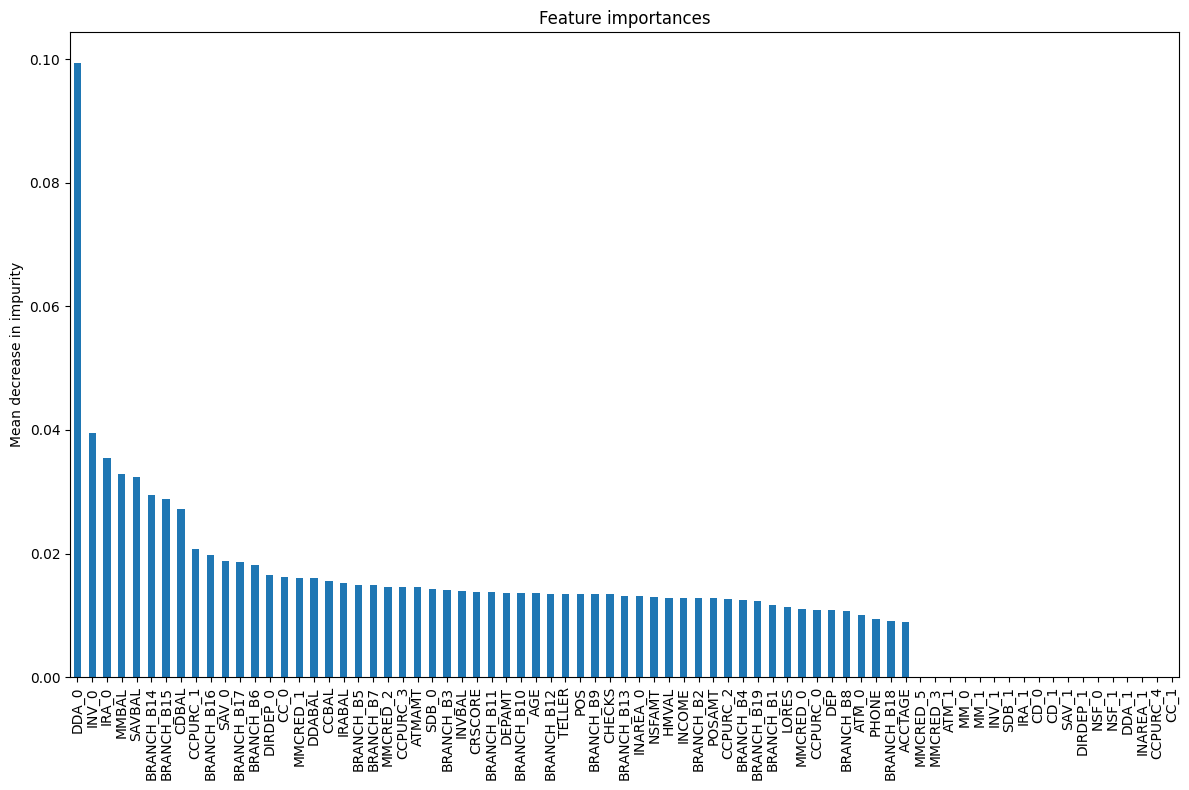

In [19]:
forest_importances = pd.Series(xgb_ins.feature_importances_, index = xgb_ins.feature_names_in_)
forest_importances = forest_importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12,8))
forest_importances.plot.bar(ax = ax)
ax.set_title("Feature importances")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

Adding a Random Variable, rerunning Feature Importance for Variable Selection (need to beat random variable to remain)
- tweak with Best Params

In [20]:
#Best parameters: {'colsample_bytree': 1, 'eta': 0.1, 'eval_metric': 'logloss', 'max_depth': 4, 'objective': 'binary:logistic', 'scale_pos_weight': 1, 'subsample': 0.75}

import numpy as np

X_train_r = X_train

X_train_r['random'] = np.random.normal(0, 1, 8495)

xgb_ins2 = XGBClassifier(n_estimators = 100,
                        subsample = 0.75,
                        eta = 0.1,
                        max_depth = 4,
                        random_state = 12345)

xgb_ins2.fit(X_train_r, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.1, eval_metric=None,
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

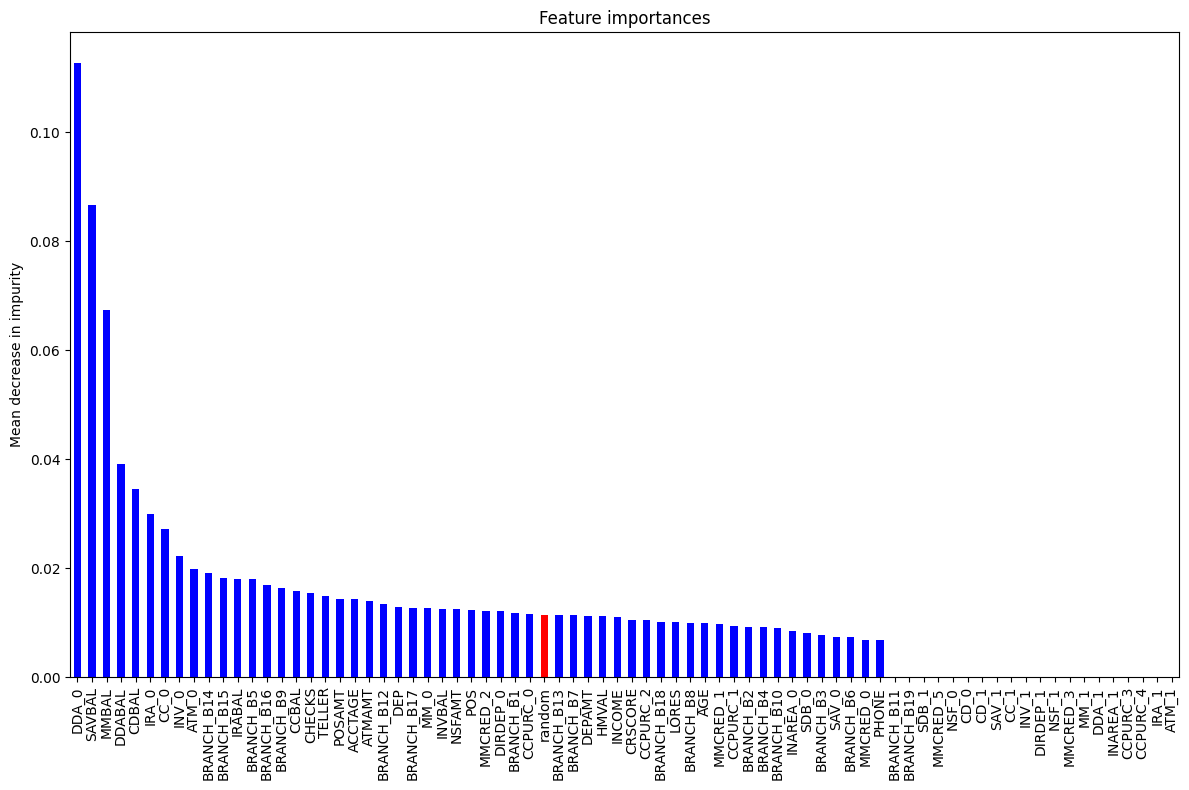

In [21]:
forest_importances = pd.Series(xgb_ins2.feature_importances_, index = xgb_ins2.feature_names_in_)
forest_importances = forest_importances.sort_values(ascending=False)

colors = ['red' if feature == 'random' else 'blue' for feature in forest_importances.index]

fig, ax = plt.subplots(figsize=(12,8))
forest_importances.plot.bar(ax = ax, color=colors)
ax.set_title("Feature importances")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

plt.show()

In [22]:
import xgboost as xgb
import pandas as pd

# Assuming `xgb_ins` is your trained XGBoost model instance

booster = xgb_ins2.get_booster()

# Get feature importance by gain, coverage, and frequency
importance_types = ['weight', 'gain', 'cover']  # weight: frequency, gain, cover: coverage

# Collect each importance type into a dictionary
importance_dict = {imp_type: booster.get_score(importance_type=imp_type) for imp_type in importance_types}

# Convert dictionaries to DataFrames, then merge them to get all values in a single DataFrame
importance_df = pd.DataFrame.from_dict(importance_dict)

# Rename columns for clarity
importance_df.columns = ['Frequency', 'Gain', 'Coverage']

# Fill NaN values with 0 (in case some features have missing importance metrics)
importance_df = importance_df.fillna(0)

# Sort by 'Gain' or another metric if desired
importance_df = importance_df.sort_values(by='Gain', ascending=False)

print(importance_df)


            Frequency       Gain    Coverage
DDA_0            20.0  55.397240  725.365112
SAVBAL           88.0  42.605095  541.412842
MMBAL            35.0  33.086231  479.518066
DDABAL          104.0  19.234550  384.848450
CDBAL            74.0  17.003853  417.476349
IRA_0            11.0  14.747686  491.744171
CC_0             15.0  13.358401  614.941406
INV_0            12.0  10.902457  757.250793
ATM_0             5.0   9.748142  369.116302
BRANCH_B14       22.0   9.434144  483.195282
BRANCH_B15       25.0   8.983179  471.312134
IRABAL           25.0   8.867483  362.257446
BRANCH_B5         1.0   8.850755  101.254204
BRANCH_B16       17.0   8.315865  594.463806
BRANCH_B9         2.0   8.067220  416.738281
CCBAL            47.0   7.791303  329.730560
CHECKS           68.0   7.599414  285.794220
TELLER           35.0   7.282107  534.941895
POSAMT           21.0   7.024128  339.556580
ACCTAGE          59.0   7.012823  311.320099
ATMAMT           67.0   6.879037  332.502014
BRANCH_B12

Re-running with Important Features

In [23]:
forest_importances

DDA_0       0.112710
SAVBAL      0.086683
MMBAL       0.067316
DDABAL      0.039134
CDBAL       0.034596
              ...   
INAREA_1    0.000000
CCPURC_3    0.000000
CCPURC_4    0.000000
IRA_1       0.000000
ATM_1       0.000000
Length: 76, dtype: float32

In [24]:
random_variable_importance = forest_importances.random

important_features = forest_importances[forest_importances > random_variable_importance]

X_train_reduced = X_train[important_features.index]

In [25]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# note: needed an XGBClassifier for binary classification, instead of the Regressor we would need for a continuous variable

# Define the parameter grid
params = {
    'objective': ['binary:logistic'],                                # Binary classification task
    'eval_metric': ['logloss'],                                      # Evaluation metric
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],                    # Depth of the tree
    'eta': [0.1, 0.15, 0.2, 0.25, 0.3],                              # Learning rate
    'subsample': [0.25, 0.5, 0.75, 1],                               # Fraction of samples to use
    'colsample_bytree': [0.5, 0.75, 1],                        # Fraction of features to use
    'scale_pos_weight': [1],                                         # Balances class weights (useful if target is imbalanced)
    "n_estimators":[50, 100, 125]
}

# Initialize the XGBClassifier model for binary classification
xgb = XGBClassifier()

# Set up the grid search with cross-validation
grid_search = GridSearchCV(estimator=xgb, param_grid=params, cv=10, scoring='roc_auc')

# Fit the model on the training data
grid_search.fit(X_train_reduced, y_train)

# Print the best parameters and best score found by GridSearchCV
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC score: {grid_search.best_score_}")


Best parameters: {'colsample_bytree': 0.75, 'eta': 0.1, 'eval_metric': 'logloss', 'max_depth': 3, 'n_estimators': 125, 'objective': 'binary:logistic', 'scale_pos_weight': 1, 'subsample': 0.5}
Best ROC-AUC score: 0.8038890857294001


In [26]:
#Best parameters: {'colsample_bytree': 1, 'eta': 0.1, 'eval_metric': 'logloss', 'max_depth': 4, 'objective': 'binary:logistic', 'scale_pos_weight': 1, 'subsample': 0.75}

import numpy as np

X_train_reduced

xgb_ins3 = XGBClassifier(n_estimators = 100,
                        subsample = 0.75,
                        eta = 0.1,
                        max_depth = 4,
                        random_state = 12345)

xgb_ins3.fit(X_train_reduced, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.1, eval_metric=None,
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

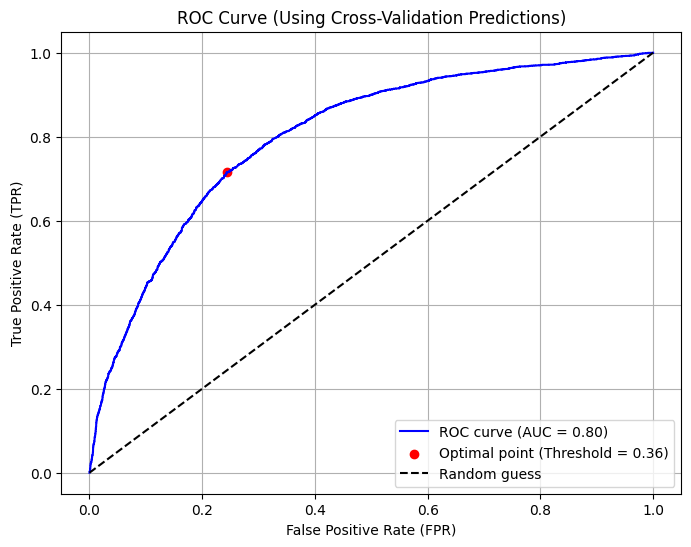

In [27]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'model' is your XGBoost classifier and 'X_train', 'y_train' are your data
# Get out-of-fold predicted probabilities
y_pred_proba = cross_val_predict(xgb_ins3, X_train_reduced, y_train, cv=5, method="predict_proba")[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba)
roc_auc = roc_auc_score(y_train, y_pred_proba)

# Calculate the optimal point
distances = np.sqrt((1 - tpr)**2 + fpr**2)  # Distance to (0, 1)
optimal_idx = np.argmin(distances)
optimal_threshold = thresholds[optimal_idx]

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", color='blue')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', 
            label=f"Optimal point (Threshold = {optimal_threshold:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.title("ROC Curve (Using Cross-Validation Predictions)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc='lower right')
plt.grid()
plt.show()


#### B. Homework 3

In [6]:
import pandas as pd

In [7]:
# get the validation dataset:
df_val = pd.read_csv("insurance_v.csv")

In [8]:
for col in conts:
    df_val[col].fillna(df_val[col].median(), inplace=True)

for col in cats:
    df_val[col].fillna(df_val[col].mode()[0], inplace=True)

df.isna().mean()

NameError: name 'conts' is not defined

In [ ]:
val_dummy = pd.get_dummies(df_val, columns=cats).astype(int)

val_dummy

,ACCTAGE,DDABAL,DEP,DEPAMT,CHECKS,NSFAMT,PHONE,TELLER,SAVBAL,ATMAMT,...,BRANCH_B18,BRANCH_B19,BRANCH_B2,BRANCH_B3,BRANCH_B4,BRANCH_B5,BRANCH_B6,BRANCH_B7,BRANCH_B8,BRANCH_B9
0,0,462,2,1049,4,0,0,2,9010,863,...,0,0,0,0,0,0,1,0,0,0
1,0,5681,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,4,1660,4,4425,6,0,1,1,668,876,...,0,0,0,0,0,0,0,0,0,0
3,2,1038,3,2191,4,0,0,4,2652,220,...,0,0,0,0,0,0,0,0,0,0
4,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2119,1,788,6,4803,15,22,0,0,468,3244,...,0,0,0,0,0,1,0,0,0,0
2120,1,82,0,0,0,0,0,0,26351,0,...,0,0,0,0,0,0,1,0,0,0
2121,1,7220,3,2762,1,0,0,1,373,2487,...,0,0,0,0,1,0,0,0,0,0
2122,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
val_dummy.rename(columns={'INV_0.0' : 'INV_0','INV_1.0':'INV_1', 'CC_0.0': 'CC_0', 'CC_1.0': 'CC_1', 'CCPURC_0.0':'CCPURC_0', 'CCPURC_1.0':'CCPURC_1',
                                    'CCPURC_2.0':'CCPURC_2', 'CCPURC_3.0':'CCPURC_3', 'CCPURC_4.0':'CCPURC_4'}, inplace=True)

In [ ]:
X_val = val_dummy.loc[:, val_dummy.columns != "INS"]

y_val = val_dummy["INS"]

In [ ]:
X_train.head()

,ACCTAGE,DDABAL,DEP,DEPAMT,CHECKS,NSFAMT,PHONE,TELLER,SAVBAL,ATMAMT,...,BRANCH_B18,BRANCH_B19,BRANCH_B2,BRANCH_B3,BRANCH_B4,BRANCH_B5,BRANCH_B6,BRANCH_B7,BRANCH_B8,BRANCH_B9
0,0,1986,1,446,1,0,0,0,0,268,...,0,0,1,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,12,1069,5,6813,13,0,2,9,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,190,3,880,1,5,0,0,11,1582,...,0,0,0,0,0,0,0,0,0,0
4,1,257,5,3408,14,60,0,1,9,3807,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_val.head()

,ACCTAGE,DDABAL,DEP,DEPAMT,CHECKS,NSFAMT,PHONE,TELLER,SAVBAL,ATMAMT,...,BRANCH_B18,BRANCH_B19,BRANCH_B2,BRANCH_B3,BRANCH_B4,BRANCH_B5,BRANCH_B6,BRANCH_B7,BRANCH_B8,BRANCH_B9
0,0,462,2,1049,4,0,0,2,9010,863,...,0,0,0,0,0,0,1,0,0,0
1,0,5681,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,4,1660,4,4425,6,0,1,1,668,876,...,0,0,0,0,0,0,0,0,0,0
3,2,1038,3,2191,4,0,0,4,2652,220,...,0,0,0,0,0,0,0,0,0,0
4,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
print(X_train.shape)
print(X_val.shape)

(8495, 75)
(2124, 74)


In [ ]:
X_train.columns

Index(['ACCTAGE', 'DDABAL', 'DEP', 'DEPAMT', 'CHECKS', 'NSFAMT', 'PHONE',
       'TELLER', 'SAVBAL', 'ATMAMT', 'POS', 'POSAMT', 'CDBAL', 'IRABAL',
       'INVBAL', 'MMBAL', 'CCBAL', 'INCOME', 'LORES', 'HMVAL', 'AGE',
       'CRSCORE', 'ATM_0', 'ATM_1', 'MM_0', 'MM_1', 'INV_0', 'INV_1', 'SDB_0',
       'SDB_1', 'IRA_0', 'IRA_1', 'CD_0', 'CD_1', 'SAV_0', 'SAV_1', 'CC_0',
       'CC_1', 'DIRDEP_0', 'DIRDEP_1', 'NSF_0', 'NSF_1', 'DDA_0', 'DDA_1',
       'INAREA_0', 'INAREA_1', 'CCPURC_0', 'CCPURC_1', 'CCPURC_2', 'CCPURC_3',
       'CCPURC_4', 'MMCRED_0', 'MMCRED_1', 'MMCRED_2', 'MMCRED_3', 'MMCRED_5',
       'BRANCH_B1', 'BRANCH_B10', 'BRANCH_B11', 'BRANCH_B12', 'BRANCH_B13',
       'BRANCH_B14', 'BRANCH_B15', 'BRANCH_B16', 'BRANCH_B17', 'BRANCH_B18',
       'BRANCH_B19', 'BRANCH_B2', 'BRANCH_B3', 'BRANCH_B4', 'BRANCH_B5',
       'BRANCH_B6', 'BRANCH_B7', 'BRANCH_B8', 'BRANCH_B9'],
      dtype='object')

In [ ]:
X_val.columns

Index(['ACCTAGE', 'DDABAL', 'DEP', 'DEPAMT', 'CHECKS', 'NSFAMT', 'PHONE',
       'TELLER', 'SAVBAL', 'ATMAMT', 'POS', 'POSAMT', 'CDBAL', 'IRABAL',
       'INVBAL', 'MMBAL', 'CCBAL', 'INCOME', 'LORES', 'HMVAL', 'AGE',
       'CRSCORE', 'ATM_0', 'ATM_1', 'MM_0', 'MM_1', 'INV_0', 'INV_1', 'SDB_0',
       'SDB_1', 'IRA_0', 'IRA_1', 'CD_0', 'CD_1', 'SAV_0', 'SAV_1', 'CC_0',
       'CC_1', 'DIRDEP_0', 'DIRDEP_1', 'NSF_0', 'NSF_1', 'DDA_0', 'DDA_1',
       'INAREA_0', 'INAREA_1', 'CCPURC_0', 'CCPURC_1', 'CCPURC_2', 'CCPURC_3',
       'CCPURC_4', 'MMCRED_0', 'MMCRED_1', 'MMCRED_2', 'MMCRED_3', 'BRANCH_B1',
       'BRANCH_B10', 'BRANCH_B11', 'BRANCH_B12', 'BRANCH_B13', 'BRANCH_B14',
       'BRANCH_B15', 'BRANCH_B16', 'BRANCH_B17', 'BRANCH_B18', 'BRANCH_B19',
       'BRANCH_B2', 'BRANCH_B3', 'BRANCH_B4', 'BRANCH_B5', 'BRANCH_B6',
       'BRANCH_B7', 'BRANCH_B8', 'BRANCH_B9'],
      dtype='object')

In [ ]:
X_val['MMCRED_5'] = 0

In [ ]:
X_val.shape

(2124, 75)

In [ ]:
y_train.shape

(8495,)

In [ ]:
y_val.shape

(2124,)

In [ ]:
## Naive Bayes model
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [ ]:
# Reindex X_val to match the column order of X_train
X_val = X_val[X_train.columns]

In [ ]:
# Make predictions on the validation dataset
y_pred = gnb.predict(X_val)

# Evaluate the model using a confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# Accuracy score
print("\nAccuracy:", accuracy_score(y_val, y_pred))

# Classification report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Confusion Matrix:
[[1294   88]
 [ 598  144]]

Accuracy: 0.6770244821092278

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.94      0.79      1382
           1       0.62      0.19      0.30       742

    accuracy                           0.68      2124
   macro avg       0.65      0.57      0.54      2124
weighted avg       0.66      0.68      0.62      2124



In [ ]:
# Get predicted probabilities
y_prob = gnb.predict_proba(X_val)

# The probabilities for the positive class (e.g., 'INS' = 1)
positive_class_probabilities = y_prob[:, 1]

# Example: Print first 5 probabilities
print("First 5 predicted probabilities for positive class:")
print(positive_class_probabilities[:5])


First 5 predicted probabilities for positive class:
[4.45024680e-04 9.99999999e-01 2.37795972e-04 1.92218631e-04
 1.24000158e-03]


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, positive_class_probabilities)

# Compute Youden index for each threshold
youden_index = tpr - fpr
optimal_idx = youden_index.argmax()
optimal_threshold = thresholds[optimal_idx]

# Get the TPR and FPR for the optimal threshold
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]


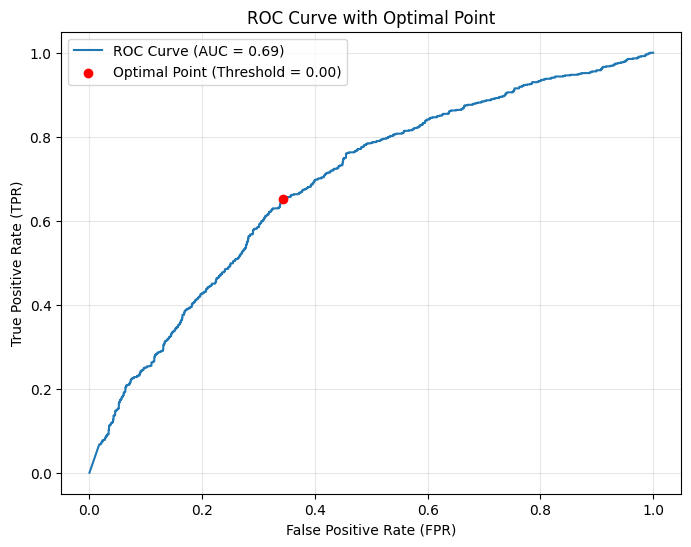

In [ ]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_val, positive_class_probabilities):.2f})")
plt.scatter(optimal_fpr, optimal_tpr, color='red', label=f"Optimal Point (Threshold = {optimal_threshold:.2f})", zorder=5)
plt.title("ROC Curve with Optimal Point")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### XG Boost is best model - run on Validation, and get feature importance
 - global variable (PDP/ALE): account_age
 - local variable (Shapley): row 732

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Initialize the XGBClassifier with best parameters
xgb_ins_final = XGBClassifier(
    n_estimators=100,
    subsample=0.75,
    eta=0.1,
    max_depth=4,
    random_state=12345
)


In [ ]:

# Fit the model on the training data
xgb_ins_final.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.1, eval_metric=None,
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:

# Predict probabilities for the positive class on validation data
y_pred_proba = xgb_ins_final.predict_proba(X_val)[:, 1]

# Calculate ROC curve and AUC for validation data
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = roc_auc_score(y_val, y_pred_proba)

# Calculate the optimal point based on minimal distance to (0, 1)
distances = np.sqrt((1 - tpr)**2 + fpr**2)  # Distance to (0, 1)
optimal_idx = np.argmin(distances)
optimal_threshold = thresholds[optimal_idx]


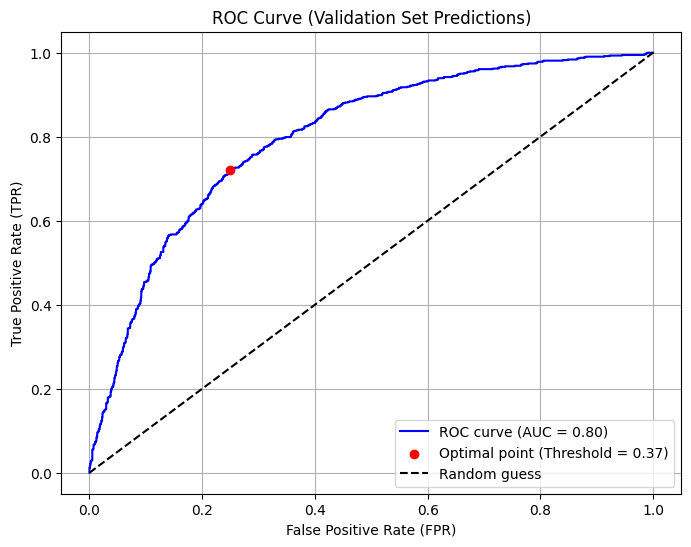

Optimal Threshold: 0.37


In [ ]:

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", color='blue')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', 
            label=f"Optimal point (Threshold = {optimal_threshold:.2f})", zorder=5)
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.title("ROC Curve (Validation Set Predictions)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print optimal threshold
print(f"Optimal Threshold: {optimal_threshold:.2f}")


#### ALE for important vars: Account Age
- global

In [ ]:
pip install interpret

Note: you may need to restart the kernel to use updated packages.


In [9]:
from interpret.blackbox import PartialDependence
from interpret import show


In [10]:

# Initialize Partial Dependence Plot explainer
pdp = PartialDependence(predict_fn=xgb_ins_final.predict, data=X_val, feature_names=X_val.columns)


NameError: name 'xgb_ins_final' is not defined

In [ ]:

# Generate global explanations for all features
pdp_global = pdp.explain_global()

# Get the top 5 features by importance
top_5_features = sorted(pdp_global.data()['scores'], reverse=True)[:5]
top_5_feature_names = [pdp_global.data()['names'][i] for i in range(len(top_5_features))]

print("Top 5 features:", top_5_feature_names)

# Generate PDP for the top 5 features
pdp_top5 = pdp.explain_global(features=top_5_feature_names)

# Visualize PDP for the top 5 features
show(pdp_top5)
